In [ ]:
# # Clone the repository to get supporting .py and .csv files
# !git clone https://github.com/laandra/Household-RL.git

# # Move into the repository directory so your imports and file paths work
# import os
# os.chdir('/content/Household-RL')

#### Import/install

##### Setup

In [4]:
### CELL 11: Install Required Libraries (stable Windows/Anaconda setup)
# %load_ext autoreload
# %autoreload 2

# Use user site-packages to avoid permission/lock issues in base Anaconda folders.
%pip install --upgrade pip
%pip install --user --index-url https://download.pytorch.org/whl/cpu torch torchvision torchaudio

%pip install xlsxwriter
%pip install optuna
%pip install stable-baselines3 gymnasium sb3-contrib
%pip install seaborn

print("After package updates, restart the kernel once before imports.")

Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
After package updates, restart the kernel once before imports.


In [84]:
### CELL 12: Import Libraries
import pandas as pd
import numpy as np
#import IPython.display as display
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
from datetime import date, datetime
#from mpl_toolkits.mplot3d import Axes3D
#from matplotlib import cm
#import io
#import base64
# for generating random values
import random
# for copying python objects
import copy
import sys

import json
from pathlib import Path

from sklearn.linear_model import LinearRegression

from enum import Enum  #Za definicijo stvari ki jih definiram z celimi števili npr, katero akcijo bomo naredili
from datetime import datetime
import seaborn as sns
import os

# try:
#     from google.colab import files #TYPE: ignore
#     IN_COLAB = True
# except ImportError:
#     IN_COLAB = False
IN_COLAB = os.path.exists('/content')    
IN_MAC = sys.platform == "darwin"
IN_WINDOWS = sys.platform == "win32"

import xlsxwriter

from pathlib import Path
import re

import torch as T
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
# import gym
from collections import deque

# 1. Check for NVIDIA CUDA (Linux/Windows)
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using NVIDIA CUDA GPU: {torch.cuda.get_device_name(0)}")

# 2. Check for Apple Silicon MPS (Mac M1/M2/M3/M4)
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon MPS Acceleration")

# 3. Fallback to CPU
else:
    device = torch.device("cpu")
    print("Using CPU")

# Example: Sending a tensor to the selected device
x = torch.rand(3, 3, device=device)
print("\nTensor created on device:", x.device)

from matplotlib.lines import Line2D
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

from Tabular_RL_SARSA import (
    LinearFunctionSarsaAgent,
    QL_trening_krajsi, QL_trening_daljsi,
    State, Action,
    BatMaxPraTrenutno, BatMaxPolTrenutno,
    PaneliOdvec, BaterijaSprememba
)

# Optional legacy helpers (kept backward-compatible if file exists)
try:
    from Normalization_Functions import normalize_dataset, ResultConverter, normalize_single_value
except ImportError:
    normalize_dataset = None
    ResultConverter = None
    normalize_single_value = None

from Environment import HouseholdEnvironment
from Ploting_Functions import plotMultiY

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Using Apple Silicon MPS Acceleration

Tensor created on device: mps:0


In [6]:
# Test 1: Check if the file exists
import os
import importlib
import sys
file_path = "Ploting_Functions.py"
print(f"File exists: {os.path.exists(file_path)}")
print(f"Current directory: {os.getcwd()}")

# Test 1b: Inspect file contents for function name
try:
    with open(file_path, "r", encoding="utf-8", errors="replace") as f:
        content = f.read()
    print(f"File length: {len(content)}")
    print(f"First 200 chars: {content[:200]!r}")
    print(f"'plotMultiY' in file: {'plotMultiY' in content}")
    for line in content.splitlines():
        if "def" in line:
            print(f"DEF LINE: {line!r}")
except Exception as e:
    print(f"Error reading file: {type(e).__name__}: {e}")

# Test 2: Import module and inspect (force reload)
try:
    if "Ploting_Functions" in sys.modules:
        del sys.modules["Ploting_Functions"]
    import Ploting_Functions as pf
    pf = importlib.reload(pf)
    print("Module imported successfully")
    print(f"Module file: {pf.__file__}")
    print(f"Has plotMultiY: {hasattr(pf, 'plotMultiY')}")
    print(f"Names containing 'plot': {[n for n in dir(pf) if 'plot' in n.lower()]}")
except Exception as e:
    print(f"Error importing module: {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()

# Test 3: Direct function import
try:
    from Ploting_Functions import plotMultiY
    print("✓ plotMultiY imported successfully")
except Exception as e:
    print(f"✗ Cannot import plotMultiY: {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()

# Test 4: Direct function access from module
try:
    _ = pf.plotMultiY
    print("✓ plotMultiY resolved from module")
except Exception as e:
    print(f"✗ Cannot access plotMultiY from module: {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()

File exists: True
Current directory: /Users/tomaz/Documents/Andraz/Household-RL
File length: 10767
First 200 chars: '### CELL 13: Function for Plotting Graphs\nimport matplotlib.pyplot as plt\nimport matplotlib.dates as mdates\nfrom datetime import date, datetime\n\n"Funkcija za risanje grafov"\ndef plotMultiY(X, Y=None, '
'plotMultiY' in file: True
DEF LINE: 'def plotMultiY(X, Y=None, X_label="X_os", Y_Label=None,'
DEF LINE: 'def plot_btr_comparison(comparison_df, metric="price_mean", title="BTR Algorithm Comparison", save=False):'
DEF LINE: 'def plot_training_progress(timestamps, rewards, prices=None, algorithm_name="BTR", title="Training Progress", save=False):'
DEF LINE: 'def plot_price_distribution(results_df, algorithm_filter=None, title="Energy Cost Distribution", save=False):'
DEF LINE: 'def plot_reward_vs_price(comparison_df, title="Reward vs Energy Cost Trade-off", save=False):'
DEF LINE: 'def plot_algorithm_ranking(comparison_df, metric="price_mean", ascending=True, title="A

##### Inport

In [39]:
#### CELL 15: Load Dataset - Adjusted to Use Relative Path for Local File

if IN_COLAB:
    from google.colab import files
    print("Running in Colab")
    VhodniPodatki = pd.read_csv("/content/Household-RL/VhodniPodatki.csv")
elif IN_WINDOWS or IN_MAC:    #Windows or MAC
    VhodniPodatki = pd.read_csv("VhodniPodatki.csv")  # Use relative path for local file ("Datasorted by user/Ausgrid 1.csv")
VhodniPodatki.index = pd.to_datetime(VhodniPodatki['Timestamp_UTC'], format='ISO8601')
VhodniPodatki = VhodniPodatki.drop(columns=['Timestamp_UTC'])
CenaMer = pd.DataFrame(VhodniPodatki["SMP"])
SoncnaMer = pd.DataFrame(VhodniPodatki["Energy_Generation"])
PorabaMer = pd.DataFrame(VhodniPodatki["Energy_Consumption"])

In [40]:
### CELL 16: Split Dataset into Training and Testing Sets
# test_size = 0.5  # test size
test_size = 1/3  # test size
train_data, test_data = train_test_split(
    VhodniPodatki,
    test_size=test_size,
    shuffle=False
)

#### Osnovne funkcije

In [41]:
### CELL 21: Define General Functions
'Definicija splosnih funkcij'

# Battery transfer limits are specified per 15-minute step.
BASE_STEP_MINUTES = 15.0
BAT_MAX_POLNJENJE_BASE = 1.5
BAT_MAX_PRAZNJENJE_BASE = 1.5

# Infer dataset resolution and adapt all per-step parameters.
step_minutes = (
    VhodniPodatki.index.to_series().sort_values().diff().dropna().dt.total_seconds().median() / 60.0
)
if not np.isfinite(step_minutes) or step_minutes <= 0:
    step_minutes = BASE_STEP_MINUTES

KorakovNaDan = int(round((24 * 60) / step_minutes))
step_scale = float(step_minutes / BASE_STEP_MINUTES)

BatMaxPolnjenje = BAT_MAX_POLNJENJE_BASE * step_scale
BatMaxPraznjenje = BAT_MAX_PRAZNJENJE_BASE * step_scale
BatKapaciteta = 20
BatUcinkovitost = 0.95
faktor_cenitve = 1

faktorN1 = 1
faktorN2 = 1
faktorN3 = 1

fc1_dims = 64
fc2_dims = 32
fc3_dims = 16

lr = 0.001
gamma = 0.99
epsilon_start = 1.0
epsilon_end = 0.01
epsilon_decay = 4e-5
batch_size = KorakovNaDan
replace_target = KorakovNaDan * 7

weight_decay = 1e-4

faktorN1 = 0
faktorN2 = 0
faktorN3 = 1
faktor_cenitve = 2/3
BatUcinkovitost = 0.95
BatKapaciteta = 20

print(
    f"Detected step: {step_minutes:.1f} min | KorakovNaDan={KorakovNaDan} | "
    f"BatMaxPolnjenje={BatMaxPolnjenje:.3f} | BatMaxPraznjenje={BatMaxPraznjenje:.3f}"
)

Detected step: 15.0 min | KorakovNaDan=96 | BatMaxPolnjenje=1.500 | BatMaxPraznjenje=1.500


In [42]:
### CELL 23: Normalize the dataset

# --- 1. CONFIGURATION ---
# Options: MinMaxScaler, StandardScaler, RobustScaler
ScalerClass = RobustScaler

# Configuration for columns
shared_cols = ['Energy_Generation', 'Energy_Consumption']
independent_cols = [c for c in train_data.columns if c not in shared_cols + ['SMP']]

# --- 2. INITIALIZE SCALERS ---
# We use **kwargs so we can pass arguments only if the scaler supports them
scaler_args = {}

if ScalerClass == MinMaxScaler:
    scaler_args['feature_range'] = (0, 1)

# Create two separate instances of the CHOSEN class
scaler_shared = ScalerClass(**scaler_args)
scaler_indep = ScalerClass(**scaler_args)

# --- 3. FIT THE SCALERS ---

# A. Shared Scaler (Stacked fit)
# Flatten combined data so the scaler learns Global Min/Max or Global Mean/Std
combined_energy_data = train_data[shared_cols].values.flatten().reshape(-1, 1)
scaler_shared.fit(combined_energy_data)

# B. Independent Scaler (Normal fit)
if independent_cols:
    scaler_indep.fit(train_data[independent_cols])

# --- 4. SMP-SPECIFIC PRICE NORMALIZATION ---
def normalize_electricity_prices(data, fit=False, params=None):
    # Ensure data is 2D for the Scaler (N samples, 1 feature)
    if data.ndim == 1:
        data = data.reshape(-1, 1)

    # --- Step 1: Outlier Detection & Flagging ---
    # Fit thresholds only on train split, then reuse on test to avoid leakage.
    if fit:
        upper_threshold = np.percentile(data, 99.5)
        lower_threshold = np.percentile(data, 0.1)
    else:
        if params is None:
            raise ValueError("params must be provided when fit=False")
        upper_threshold = params['upper_threshold']
        lower_threshold = params['lower_threshold']

    # Create binary flag: 1 if it's an extreme event, 0 otherwise
    # We convert to float so it plays nice with neural network inputs
    outlier_flag = ((data > upper_threshold) | (data < lower_threshold)).astype(float)

    # --- Step 2: Log Transformation ---
    # np.maximum(data, 0) handles rare negative prices before log1p
    log_data = np.log1p(np.maximum(data, 0))

    # --- Step 3: Clipping (Winsorization) ---
    # We clip the log-data to the same percentiles used for the flag
    # This prevents the DQN gradients from exploding during those ~2 days a year
    log_lower = np.log1p(max(0, lower_threshold))
    log_upper = np.log1p(max(0, upper_threshold))
    clipped_data = np.clip(log_data, log_lower, log_upper)

    # --- Step 4: Robust Scaling ---
    # Fit scaler on train, reuse for test.
    if fit:
        scaler = RobustScaler()
        normalized_prices = scaler.fit_transform(clipped_data)
        fitted_params = {
            'upper_threshold': float(upper_threshold),
            'lower_threshold': float(lower_threshold),
            'log_lower': float(log_lower),
            'log_upper': float(log_upper),
            'scaler': scaler,
        }
    else:
        scaler = params['scaler']
        normalized_prices = scaler.transform(clipped_data)
        fitted_params = params

    # Return normalized price, outlier flag and fitted params for reuse.
    return normalized_prices, outlier_flag, fitted_params

# --- 5. APPLY TRANSFORMATION FUNCTION ---
def apply_scaling(df, scaler_shared, scaler_indep, shared_cols, indep_cols):
    df_scaled = df.copy()

    # Transform Shared Columns
    # We must transform one by one because scaler_shared expects a single column input shape
    for col in shared_cols:
        col_values = df[col].values.reshape(-1, 1)
        # flatten() ensures we put a 1D array back into the dataframe
        df_scaled[col] = scaler_shared.transform(col_values).flatten()

    # Transform Independent Columns
    if indep_cols:
        df_scaled[indep_cols] = scaler_indep.transform(df[indep_cols])

    return df_scaled

# --- 6. EXECUTE ---
train_data_norm = apply_scaling(train_data, scaler_shared, scaler_indep, shared_cols, independent_cols)
test_data_norm = apply_scaling(test_data, scaler_shared, scaler_indep, shared_cols, independent_cols)

train_smp_norm, train_smp_outlier, price_norm_params = normalize_electricity_prices(train_data['SMP'].values, fit=True)
test_smp_norm, test_smp_outlier, _ = normalize_electricity_prices(test_data['SMP'].values, fit=False, params=price_norm_params)

train_data_norm['SMP'] = train_smp_norm.flatten()
test_data_norm['SMP'] = test_smp_norm.flatten()
train_data_norm['SMP_OutlierFlag'] = train_smp_outlier.flatten()
test_data_norm['SMP_OutlierFlag'] = test_smp_outlier.flatten()

print(f"Using Scaler: {ScalerClass.__name__}")
print(train_data_norm.head())



Using Scaler: RobustScaler
                                SMP  Energy_Consumption  Energy_Generation  \
Timestamp_UTC                                                                
2018-10-03 21:00:00+00:00 -0.336438               0.625             -0.375   
2018-10-03 21:15:00+00:00 -0.336438               0.500             -0.375   
2018-10-03 21:30:00+00:00 -0.336438               0.500             -0.375   
2018-10-03 21:45:00+00:00 -0.336438               0.500             -0.375   
2018-10-03 22:00:00+00:00 -1.180522               0.375             -0.375   

                           Energy_Flow_Quarter  SMP_OutlierFlag  
Timestamp_UTC                                                    
2018-10-03 21:00:00+00:00             0.932236              0.0  
2018-10-03 21:15:00+00:00             0.932236              0.0  
2018-10-03 21:30:00+00:00             0.932236              0.0  
2018-10-03 21:45:00+00:00             0.932236              0.0  
2018-10-03 22:00:00+00:00     

#### Environment/okolje

* Nazačetku igre je baterija na pol polna
* V vsakem trenutku mora agent izbrati eno od 4 akcij


1.   Lahko kupi energijo iz omrežja in z njo napaja hišo in baterijo
2.   Lahko porabi energijo izbaterije za napajanje hiše in prodajo v omrežje
3.   Lahko kupi energijo iz omrežja samo za napajanje hiše
4.   lahko uporabi energijo iz baterije samo za napajanje hiše

* Osnovno pravilo je, da se generacija vedno najprej poravi za porabo v 1 izbiri to pomeni, da se hiša in baterija napajata s polno močjo najprej dodamo moč panelov nato po potrebi dodamo energijo iz omrežja da to dosežemos
* Nagrada je estavljena iz 3 delov prvi del omeji maksimalno in minimalno napolnjenost baterije
* Drugi del nagrajuje če je razmerje med polnjenjem baterije in ceno ustrezno - če se baterija polni pri nadpovprečni ceni energije smo zato kaznovani
* In tretji del je enostavno cena ki smo jo plačali

In [43]:
### CELL 31: Use Gymnasium Environment (HouseholdEnvironment)
def build_dqn_env(
    dataset,
    dataset_norm,
    episode_length,
    reset_mode="deterministic",
    observation_mode="sliding_window",
):
    return HouseholdEnvironment(
        dataset=dataset,
        dataset_norm=dataset_norm,
        observation_mode=observation_mode,
        reset_mode=reset_mode,
        episode_length=episode_length,
        korakov_na_dan=KorakovNaDan,
        bat_kapaciteta=BatKapaciteta,
        bat_ucinkovitost=BatUcinkovitost,
        bat_max_polnjenje=BatMaxPolnjenje,
        bat_max_praznjenje=BatMaxPraznjenje,
        faktor_cenitve=faktor_cenitve,
        faktor_n1=faktorN1,
        faktor_n2=faktorN2,
        faktor_n3=faktorN3,
    )

print("Notebook DQN now uses HouseholdEnvironment directly")

Notebook DQN now uses HouseholdEnvironment directly


In [44]:
### CELL 32: Create SARSA Environments and Train Agent
# %%time
# Build SARSA train/test environments directly with the shared gym env API
sarsa_train_env = build_dqn_env(
    dataset=train_data,
    dataset_norm=train_data_norm,
    episode_length=len(train_data) - 1,
    reset_mode="deterministic",
    observation_mode="compact",
)

sarsa_test_env = build_dqn_env(
    dataset=test_data,
    dataset_norm=test_data_norm,
    episode_length=len(test_data) - 1,
    reset_mode="deterministic",
    observation_mode="compact",
)

# Create and train agent
agent_train = LinearFunctionSarsaAgent(sarsa_train_env)
agent_test = LinearFunctionSarsaAgent(sarsa_test_env)

agent_train.set_alfa(0.003)
agent_train.set_discount_factor(0.9)  # 0.03

theta_trening, agent_train = QL_trening_krajsi(agent_train, env=sarsa_train_env)
agent_test.train(1, theta_trening, 0, 0, 0, env=sarsa_test_env)

print(f'cena po optimizaciji {agent_test.Price[-1]}')

cena po optimizaciji 910.8475537563094


## DQN

##### Setup DQN

In [45]:
class DeepQNetwork(nn.Module):
    def __init__(self, lr, layer_dims, weight_decay=1e-4):
        super(DeepQNetwork, self).__init__()
        self.layer_dims = list(layer_dims)

        self.layers = nn.ModuleList([
            nn.Linear(in_dim, out_dim)
            for in_dim, out_dim in zip(self.layer_dims[:-1], self.layer_dims[1:])
        ])

        self.optimizer = optim.AdamW(self.parameters(), lr=lr, weight_decay=weight_decay)
        #self.loss = nn.MSELoss()
        # SmoothL1 (Huber) is typically more stable than MSE for noisy TD targets.
        self.loss = nn.SmoothL1Loss(beta=1.0)

        self.device = T.device('cuda:0' if T.cuda.is_available() else 'cpu')

        nn.init.constant_(self.layers[-1].bias, 0.1)
        self.to(self.device)

    def forward(self, state):
        x = state
        for layer in self.layers[:-1]:
            x = F.relu(layer(x))
        return self.layers[-1](x)


class AgentDQN:
    def __init__(
        self,
        gamma,
        epsilon,
        lr,
        state_shape,
        network_dims,
        batch_size,
        replace_target=replace_target,
        max_mem_size=1_000_000,
        eps_end=0.05,
        eps_dec=4e-5,
        weight_decay=weight_decay,
        tau=0.005,
        start_learning_after=None,
    ):
        self.gamma = gamma
        self.epsilon = epsilon
        self.eps_min = eps_end
        self.eps_dec = eps_dec
        self.lr = lr
        self.batch_size = batch_size
        self.mem_size = max_mem_size
        self.mem_cntr = 0
        self.iter_cntr = 0
        self.replace_target = replace_target
        self.tau = float(tau) if tau is not None else 0.0

        self.state_shape = list(state_shape)
        self.network_dims = list(network_dims)
        self.n_actions = self.network_dims[-1]
        self.action_space = list(range(self.n_actions))

        self.Q_eval = DeepQNetwork(lr=lr, layer_dims=self.network_dims, weight_decay=weight_decay)
        self.Q_target = DeepQNetwork(lr=lr, layer_dims=self.network_dims, weight_decay=weight_decay)
        self.Q_target.load_state_dict(self.Q_eval.state_dict())
        self.Q_target.eval()

        if start_learning_after is None:
            self.start_learning_after = int(4 * self.batch_size)
        else:
            self.start_learning_after = int(max(start_learning_after, self.batch_size))

        self.state_memory = np.zeros((self.mem_size, *self.state_shape), dtype=np.float32)
        self.new_state_memory = np.zeros((self.mem_size, *self.state_shape), dtype=np.float32)
        self.action_memory = np.zeros(self.mem_size, dtype=np.int32)
        self.reward_memory = np.zeros(self.mem_size, dtype=np.float32)
        self.terminal_memory = np.zeros(self.mem_size, dtype=np.bool_)

    def store_transition(self, state, action, reward, state_, terminal):
        index = self.mem_cntr % self.mem_size
        self.state_memory[index] = state
        self.new_state_memory[index] = state_
        self.reward_memory[index] = reward
        self.action_memory[index] = action
        self.terminal_memory[index] = terminal

        self.mem_cntr += 1

    def choose_action(self, observation):
        if np.random.random() > self.epsilon:   #Epsilon greedy
            state = T.tensor(np.array([observation]), dtype=T.float32).to(self.Q_eval.device)   #Pripravi vektor state za naslenji korak
            actions = self.Q_eval.forward(state)    #Požene stanja čez nevronsko mrežo in si zapomni vrednosti za vse akcije
            action = T.argmax(actions).item()       #Izbere akcijo, ki naj bi ila najboljša
            # print(f"Chose action {action} with Q-values {actions.cpu().detach().numpy()} and epsilon {self.epsilon:.4f}")
        else:
            action = np.random.choice(self.action_space)

        return action

    def _soft_update_target(self):
        with T.no_grad():
            for target_param, eval_param in zip(self.Q_target.parameters(), self.Q_eval.parameters()):
                target_param.data.mul_(1.0 - self.tau).add_(self.tau * eval_param.data)

    def learn(self):
        if self.mem_cntr < self.start_learning_after:
            return

        max_mem = min(self.mem_cntr, self.mem_size)  #Velikost zasedenega spomina ko state_memory prvič napolnimo ostane mem_size
        if max_mem < self.batch_size:
            return

        batch = np.random.choice(max_mem, self.batch_size, replace=False)   #Vrne batch_size lokacij iz spomina ki se ne ponavljajo replace=False
        batch_index = np.arange(self.batch_size, dtype=np.int32)            #Ustvari vektor celih števil od 0 pa do batch_size

        state_batch = T.tensor(self.state_memory[batch], dtype=T.float32, device=self.Q_eval.device)
        new_state_batch = T.tensor(self.new_state_memory[batch], dtype=T.float32, device=self.Q_eval.device)
        action_batch_t = T.tensor(self.action_memory[batch], dtype=T.long, device=self.Q_eval.device)
        reward_batch = T.tensor(self.reward_memory[batch], dtype=T.float32, device=self.Q_eval.device)
        terminal_batch_t = T.tensor(self.terminal_memory[batch], dtype=T.float32, device=self.Q_eval.device)

        q_eval_all = self.Q_eval(state_batch)
        q_eval = q_eval_all[batch_index, action_batch_t]

        with T.no_grad():
            next_actions = self.Q_eval(new_state_batch).argmax(dim=1, keepdim=True)

            # B) Vrednotenje akcije z Q_TARGET mrežo
            # Vprašamo ciljno mrežo: "Kakšna je vrednost te akcije, ki jo je izbrala glavna mreža?"
            q_next = self.Q_target(new_state_batch).gather(1, next_actions).squeeze(1)

            # C) Končna ciljna vrednost (Bellmanova enačba)
            # Če je stanje terminalno, je q_next enak 0
            q_target = reward_batch + self.gamma * q_next * (1 - terminal_batch_t)


        loss = self.Q_eval.loss(q_eval, q_target).to(self.Q_eval.device)
        self.Q_eval.optimizer.zero_grad()   #Pozabimo staro vrednost sicer jo pytorch avtomatsko združi z novo in pride do napake
        loss.backward()     #Sproži backpropagation napake da se popravijo tudi predvidena stanja, ki so pripeljala do tegas
        T.nn.utils.clip_grad_norm_(self.Q_eval.parameters(), max_norm=1.0)  #Gradient clipping for stability
        self.Q_eval.optimizer.step()    #Posodobi parametre modela ki smo jih dobili z prejšnjim korakom

        self.iter_cntr += 1
        self.epsilon = self.epsilon - self.eps_dec if self.epsilon > self.eps_min else self.eps_min

        if self.tau > 0.0:
            self._soft_update_target()
        elif self.iter_cntr % self.replace_target == 0:
            self.Q_target.load_state_dict(self.Q_eval.state_dict())

In [46]:
import datetime as dt
import os
import time
import random


def _save_dqn_checkpoint(agent, checkpoint_file, network_dims, episode_idx=None, extra=None):
    payload = {
        "state_dict": agent.Q_eval.state_dict(),
        "network_dims": list(network_dims),
        "episode": int(episode_idx) if episode_idx is not None else None,
        "saved_at": dt.datetime.now().isoformat(),
    }
    if extra:
        payload.update(extra)

    tmp_file = checkpoint_file + ".tmp"
    T.save(payload, tmp_file)
    os.replace(tmp_file, checkpoint_file)


def set_global_seed(seed):
    if seed is None:
        return

    random.seed(seed)
    np.random.seed(seed)
    T.manual_seed(seed)

    if T.cuda.is_available():
        T.cuda.manual_seed_all(seed)
        T.backends.cudnn.deterministic = True
        T.backends.cudnn.benchmark = False


def _update_optimizer_lr(agent, new_lr):
    if new_lr is None:
        return

    if hasattr(agent, "Q_eval") and hasattr(agent.Q_eval, "optimizer"):
        for group in agent.Q_eval.optimizer.param_groups:
            group["lr"] = float(new_lr)

    if hasattr(agent, "Q_target") and hasattr(agent.Q_target, "optimizer"):
        for group in agent.Q_target.optimizer.param_groups:
            group["lr"] = float(new_lr)

    agent.lr = float(new_lr)


def Learning_DQN(epsilon=None, reset=False, ponovitev=52, epsilon_decay=None,
                 epsilon_end=None, analiziran_kos=None, ucenje=True, random=False,
                 lr=None, agent=None, env=None,
                 eval_epsilon=0.0, seed=None,
                 deterministic_starts=False, start_learning_after=None,
                 checkpoint_every=5, diag_tag="dqn"):

    # Resolve defaults at call time so Optuna-updated globals are used.
    if epsilon is None:
        epsilon = epsilon_start
    if epsilon_decay is None:
        epsilon_decay = globals().get("epsilon_decay")
    if epsilon_end is None:
        epsilon_end = globals().get("epsilon_end")
    if analiziran_kos is None:
        analiziran_kos = batch_size
    if lr is None:
        lr = globals().get("lr")

    set_global_seed(seed)

    episodes = ponovitev
    shrani = True
    nalozi = (agent is None)

    data = train_data if ucenje else test_data
    data_norm = train_data_norm if ucenje else test_data_norm

    if not ucenje:
        shrani = False
        nalozi = (agent is None)
        epsilon = 0
        epsilon_end = 0
        episodes = 1
        steps_per_episode = len(data) - 1
    else:
        steps_per_episode = KorakovNaDan * 7

    if random:
        epsilon = 1
        epsilon_end = 1

    # Build gym environment if not provided.
    if env is None or reset:
        env_reset_mode = "deterministic" if (not ucenje or deterministic_starts) else "random"
        env = build_dqn_env(
            dataset=data,
            dataset_norm=data_norm,
            episode_length=steps_per_episode,
            reset_mode=env_reset_mode,
            observation_mode="sliding_window",
        )

    old_agent_epsilon = None

    state_shape = [int(env.observation_space.shape[0])]
    network_dims = [state_shape[0], fc1_dims, fc2_dims, fc3_dims, len(Action)]

    if agent is None or reset:
        agent = AgentDQN(
            gamma=gamma,
            epsilon=epsilon,
            lr=lr,
            state_shape=state_shape,
            network_dims=network_dims,
            batch_size=analiziran_kos,
            eps_end=epsilon_end,
            eps_dec=epsilon_decay,
            replace_target=replace_target,
            weight_decay=weight_decay,
            start_learning_after=start_learning_after,
        )
    else:
        # Keep continuation runs consistent when reusing an already-trained agent.
        agent.epsilon = float(epsilon)
        agent.eps_min = float(epsilon_end)
        agent.eps_dec = float(epsilon_decay)
        agent.batch_size = int(analiziran_kos)
        if start_learning_after is not None:
            agent.start_learning_after = int(max(start_learning_after, agent.batch_size))
        _update_optimizer_lr(agent, lr)

    nagradaDQN, placiloDQN = [0], [0]
    NagradaKapaciteta, NagradaSprememba, NagradaPlacilo = [0], [0], [0]
    baterijaDQN = [BatKapaciteta / 2]

    name = "dqn_model"
    chkpt_dir = "DQN"
    checkpoint_dir = chkpt_dir

    if not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)
    checkpoint_file = os.path.join(checkpoint_dir, name)

    # Reset mode must start from clean weights even if a previous checkpoint exists.
    if reset:
        nalozi = False
        if os.path.exists(checkpoint_file):
            try:
                os.remove(checkpoint_file)
                print("Reset requested: removed old DQN checkpoint.")
            except OSError as exc:
                msg = f"Reset requested: could not remove old checkpoint ({exc}). Continuing without loading."
                print(msg)

    ckpt_dims = None
    state_dict = None
    if nalozi and os.path.exists(checkpoint_file):
        ckpt = T.load(checkpoint_file, weights_only=False)

        # Backward compatibility: old checkpoints may be plain state_dict.
        if isinstance(ckpt, dict) and "state_dict" in ckpt:
            state_dict = ckpt["state_dict"]
            ckpt_dims = ckpt.get("network_dims", None)
        else:
            state_dict = ckpt
            ckpt_dims = None

    if nalozi and state_dict is not None:
        if (ckpt_dims is None) or (list(ckpt_dims) == list(network_dims)):
            agent.Q_eval.load_state_dict(state_dict)
            agent.Q_target.load_state_dict(agent.Q_eval.state_dict())
            agent.Q_target.eval()
        else:
            print("Skipping checkpoint load: architecture mismatch.")
    elif nalozi:
        print("Checkpoint not found; starting from randomly initialized weights.")

    if not ucenje:
        # eval_epsilon=0.0  -> deterministic (greedy), > 0 -> stochastic robustness test
        if not random:
            old_agent_epsilon = agent.epsilon
            agent.epsilon = float(eval_epsilon)
            if eval_epsilon > 0.0:
                print(f"Stochastic eval: epsilon = {eval_epsilon:.4f}")
            else:
                print("Deterministic eval: epsilon = 0.0 (greedy)")
        if random:
            agent.epsilon = 1.0
            print("Random eval: epsilon = 1.0")

    print(f"Episode: {episodes}")
    print(f"Steps per episode: {steps_per_episode}")

    for i in range(episodes):
        done = False
        episode_reward = 0.0

        if not ucenje:
            reset_options = {"reset_mode": "deterministic"}
        else:
            if deterministic_starts:
                reset_options = {"reset_mode": "sequential", "sequential_n": max(episodes, 1)}
            else:
                reset_options = {"reset_mode": "random"}

        try:
            obs, info = env.reset(options=reset_options)
            print(f"Epsilon {agent.epsilon:.4f}")

            step_count = 0
            while step_count < steps_per_episode and not done:
                action = agent.choose_action(obs)
                next_obs, reward, terminated, truncated, step_info = env.step(action)
                done_next = bool(terminated or truncated)

                if ucenje:
                    agent.store_transition(obs, action, reward, next_obs, done_next)
                    agent.learn()

                obs = next_obs
                done = done_next
                step_count += 1
                episode_reward += reward

                nagradaDQN.append(nagradaDQN[-1] + reward)
                placiloDQN.append(float(step_info.get("cumulative_payment", placiloDQN[-1])))
                baterijaDQN.append(float(step_info.get("battery", baterijaDQN[-1])))

                reward_components = step_info.get("reward_components", {})
                NagradaKapaciteta.append(float(reward_components.get("r_kapaciteta", 0.0)))
                NagradaSprememba.append(float(reward_components.get("r_sprememba", 0.0)))
                NagradaPlacilo.append(float(reward_components.get("r_placilo", 0.0)))

            if shrani and (((i + 1) % max(int(checkpoint_every), 1)) == 0 or (i + 1) == episodes):
                _save_dqn_checkpoint(
                    agent,
                    checkpoint_file,
                    network_dims,
                    episode_idx=i + 1,
                    extra={
                        "epsilon": float(agent.epsilon),
                        "learning": bool(ucenje),
                    },
                )

        except Exception:
            if shrani:
                _save_dqn_checkpoint(
                    agent,
                    checkpoint_file,
                    network_dims,
                    episode_idx=i,
                    extra={
                        "epsilon": float(agent.epsilon),
                        "learning": bool(ucenje),
                    },
                )
            raise

    if shrani:
        _save_dqn_checkpoint(
            agent,
            checkpoint_file,
            network_dims,
            episode_idx=episodes,
            extra={
                "epsilon": float(agent.epsilon),
                "learning": bool(ucenje),
            },
        )

    if old_agent_epsilon is not None:
        agent.epsilon = old_agent_epsilon

    if not ucenje:
        print(f"Final price: {placiloDQN[-1]:.2f} EUR")
        return nagradaDQN, placiloDQN, baterijaDQN, NagradaKapaciteta, NagradaSprememba, NagradaPlacilo
    else:
        return agent, env

##### Optimization

In [ ]:
# Optimization horizons
OPT_EPISODES = 35
OPT_HORIZON = KorakovNaDan * 14


def objective(trial):
    gamma_t = trial.suggest_float("gamma", 0.8, 0.99999, log=True)
    lr_t = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    epsilon_start_t = trial.suggest_float("epsilon_start", 0.8, 1.0)
    epsilon_end_t = trial.suggest_float("epsilon_end", 0.01, 0.15)
    epsilon_decay_t = trial.suggest_float("epsilon_decay", 1e-6, 2e-4, log=True)
    batch_size_t = trial.suggest_categorical("batch_size", [32, 64, 96, 128])
    fc1_t = 512        #trial.suggest_categorical("fc1_dims", [128, 256, 512])
    fc2_t = 256        #trial.suggest_categorical("fc2_dims", [64, 128, 256])
    fc3_t = 128     #trial.suggest_categorical("fc3_dims", [32, 64, 128])
    replace_target_t = trial.suggest_int("replace_target", KorakovNaDan * 3, KorakovNaDan * 30)
    weight_decay_t = trial.suggest_float("weight_decay", 0.0, 1e-3)

    env = build_dqn_env(
        dataset=train_data,
        dataset_norm=train_data_norm,
        episode_length=OPT_HORIZON,
        reset_mode="random",
        observation_mode="sliding_window",
    )

    state_shape = [int(env.observation_space.shape[0])]
    network_dims = [state_shape[0], fc1_t, fc2_t, fc3_t, len(Action)]

    agent = AgentDQN(
        gamma=gamma_t,
        epsilon=epsilon_start_t,
        lr=lr_t,
        state_shape=state_shape,
        network_dims=network_dims,
        batch_size=batch_size_t,
        eps_end=epsilon_end_t,
        eps_dec=epsilon_decay_t,
        weight_decay=weight_decay_t,
        replace_target=replace_target_t,
    )

    total_reward = 0.0

    for episode in range(OPT_EPISODES):
        obs, _ = env.reset(options={"reset_mode": "random"})
        episode_reward = 0.0

        for step in range(OPT_HORIZON):
            a = agent.choose_action(obs)
            next_obs, r, terminated, truncated, _ = env.step(a)
            done = bool(terminated or truncated)

            agent.store_transition(obs, a, r, next_obs, done)
            agent.learn()

            obs = next_obs
            episode_reward += r

            if done:
                break

        total_reward += episode_reward
        score = total_reward / (episode + 1)

        trial.report(score, episode)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return total_reward / OPT_EPISODES


study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5),
)

print("Starting hyperparameter optimization...")
study.optimize(objective, n_trials=100, timeout=3600)

print("Optimization completed.")
print(f"Finished trials: {len(study.trials)}")
print(f"Best trial: {study.best_trial.number}")
print(f"Best value: {study.best_trial.value:.4f}")

best_params = study.best_trial.params

plot_optimization_history(study).show()
plot_param_importances(study).show()

In [ ]:
# apply best Optuna parameters
gamma = best_params['gamma']
lr = best_params['lr']
epsilon_start = best_params['epsilon_start']
epsilon_end = best_params['epsilon_end']
epsilon_decay = best_params['epsilon_decay']
batch_size = best_params['batch_size']
# fc1_dims = best_params['fc1_dims']
# fc2_dims = best_params['fc2_dims']
# fc3_dims = best_params['fc3_dims']
replace_target = best_params['replace_target']
weight_decay = best_params['weight_decay']

##### Best param save/load

In [ ]:
if IN_COLAB:
    base_dir = Path("/content/drive/MyDrive/Colab Notebooks")
else:
    # Path(".") points to your current working directory on both Mac and Windows
    base_dir = Path(".") 

# Path combining handles the slashes automatically (e.g., '\' for Windows, '/' for Mac/Colab)
best_param_loc = base_dir / "Optimized hyperparameters" / "N001Fc66Bu95Bk20VecjimNN-AUSGRID-GYM.json"

# Save best Optuna parameters to file
with open(best_param_loc, "w") as f:
    json.dump(best_params, f, indent=4)

print(f"Best parameters saved to {best_param_loc}")
print(best_params)


In [47]:
if IN_COLAB:
    best_param_loc = "/content/Household-RL/Optimized hyperparameters/N011Fc66Bu95Bk20PoskusZVecjimNN.json"
else:
    best_param_loc = "Optimized hyperparameters/N011Fc66Bu95Bk20PoskusZVecjimNN.json"
# Load best parameters from file
with open(best_param_loc, "r") as f:
    best_params = json.load(f)

gamma = best_params['gamma']
lr = best_params['lr']
epsilon_start = best_params['epsilon_start']
epsilon_end = best_params['epsilon_end']
epsilon_decay = best_params['epsilon_decay']
batch_size = best_params['batch_size']
fc1_dims = best_params['fc1_dims']
fc2_dims = best_params['fc2_dims']
fc3_dims = best_params['fc3_dims']
replace_target = best_params['replace_target']
weight_decay = best_params['weight_decay']

print("Loaded best parameters from BestParam1.json")
print(best_params)


Loaded best parameters from BestParam1.json
{'gamma': 0.9857302559125477, 'lr': 1.1584493457792702e-05, 'epsilon_start': 0.8737665045005893, 'epsilon_end': 0.016776902971714826, 'epsilon_decay': 3.44354532885725e-05, 'batch_size': 96, 'fc1_dims': 512, 'fc2_dims': 256, 'fc3_dims': 64, 'replace_target': 901, 'weight_decay': 0.0003022167240849796}


##### Uporaba DQN

In [16]:
faktorN1 = 0
faktorN2 = 0
faktorN3 = 1
faktor_cenitve = 2/3
BatUcinkovitost = 0.95
BatKapaciteta = 20

In [ ]:
# TESTING HYPERPARAMETERS
# gamma = 0.95
# weight_decay = 0.000

In [95]:
cuda_available = T.cuda.is_available()
mps_available = T.backends.mps.is_available()

print(f"CUDA (NVIDIA) available: {cuda_available}")
print(f"MPS (Apple Silicon) available: {mps_available}")
print("-" * 30)

# Determine the best available device
if cuda_available:
    device = T.device("cuda")
    print(f"Using device: {T.cuda.get_device_name(0)}")
elif mps_available:
    device = T.device("mps")
    print("Using device: Apple Silicon GPU (MPS)")
else:
    device = T.device("cpu")
    print("Running on CPU")

# print('Current NN architecture:', (state_shape[0], fc1_dims, fc2_dims, fc3_dims, len(Action)))

CUDA (NVIDIA) available: False
MPS (Apple Silicon) available: True
------------------------------
Using device: Apple Silicon GPU (MPS)


In [17]:
%%time
train = Learning_DQN(reset = True) #, ponovitev=100
nagradaDQN , placiloDQN, baterijaDQN, NagradaKapaciteta, NagradaSprememba, NagradaPlacilo= Learning_DQN(ucenje=False)
print(f'Nagrada po optimizaciji {nagradaDQN[-1]}')
print(f'Cena po optimizaciji {placiloDQN[-1]}')
print(f'faktorN1: {faktorN1}')
print(f'faktorN2: {faktorN2}')
print(f'faktorN3: {faktorN3}')

Reset requested: removed old DQN checkpoint.
Episode: 52
Steps per episode: 336
Epsilon 0.8738
Epsilon 0.8738
Epsilon 0.8639
Epsilon 0.8523
Epsilon 0.8408
Epsilon 0.8293
Epsilon 0.8177
Epsilon 0.8062
Epsilon 0.7947
Epsilon 0.7831
Epsilon 0.7716
Epsilon 0.7601
Epsilon 0.7485
Epsilon 0.7370
Epsilon 0.7255
Epsilon 0.7139
Epsilon 0.7024
Epsilon 0.6908
Epsilon 0.6793
Epsilon 0.6678
Epsilon 0.6562
Epsilon 0.6447
Epsilon 0.6332
Epsilon 0.6216
Epsilon 0.6101
Epsilon 0.5986
Epsilon 0.5870
Epsilon 0.5755
Epsilon 0.5640
Epsilon 0.5524
Epsilon 0.5409
Epsilon 0.5293
Epsilon 0.5178
Epsilon 0.5063
Epsilon 0.4947
Epsilon 0.4832
Epsilon 0.4717
Epsilon 0.4601
Epsilon 0.4486
Epsilon 0.4371
Epsilon 0.4255
Epsilon 0.4140
Epsilon 0.4024
Epsilon 0.3909
Epsilon 0.3794
Epsilon 0.3678
Epsilon 0.3563
Epsilon 0.3448
Epsilon 0.3332
Epsilon 0.3217
Epsilon 0.3102
Epsilon 0.2986
Deterministic eval: epsilon = 0.0 (greedy)
Episode: 1
Steps per episode: 17535
Epsilon 0.0000
Final price: 73.23 EUR
Nagrada po optimizaciji

In [ ]:
# Quick validation after reward-scaling fix
quick_agent, quick_env = Learning_DQN(reset=True, ponovitev=15)
quick_eval_env = Environment_DQN(test_data, test_data_norm)
quick_nagrada, quick_placilo, quick_baterija, _, _, _ = Learning_DQN(
    ucenje=False, agent=quick_agent, env=quick_eval_env
 )
print(f"Quick DQN price: {quick_placilo[-1]:.2f} EUR")
if 'agent_brez_baterije' in globals():
    print(f"No-battery price: {agent_brez_baterije.Price[-1]:.2f} EUR")
    print(f"DQN improvement vs no battery: {agent_brez_baterije.Price[-1] - quick_placilo[-1]:.2f} EUR")
if 'agent_test' in globals():
    print(f"SARSA price: {agent_test.Price[-1]:.2f} EUR")
    print(f"DQN gap vs SARSA: {quick_placilo[-1] - agent_test.Price[-1]:.2f} EUR")

In [ ]:
faktorN1 = 0
faktorN2 = 1
faktorN3 = 0
train_agent, train_env = Learning_DQN(reset = True) #, ponovitev=100
nagradaDQN , placiloDQN, baterijaDQN, NagradaKapaciteta, NagradaSprememba, NagradaPlacilo= Learning_DQN(ucenje=False)
print(f'Nagrada po optimizaciji {nagradaDQN[-1]}')
print(f'Cena po optimizaciji {placiloDQN[-1]}')
print(f'faktorN1: {faktorN1}')
print(f'faktorN2: {faktorN2}')
print(f'faktorN3: {faktorN3}')
faktorN1 = 0
faktorN2 = 0
faktorN3 = 1
train_agent, train_env = Learning_DQN(lr=lr/5, agent=train_agent, env=train_env)
nagradaDQN , placiloDQN, baterijaDQN, NagradaKapaciteta, NagradaSprememba, NagradaPlacilo= Learning_DQN(ucenje=False)
print(f'Nagrada po optimizaciji {nagradaDQN[-1]}')
print(f'Cena po optimizaciji {placiloDQN[-1]}')
print(f'faktorN1: {faktorN1}')
print(f'faktorN2: {faktorN2}')
print(f'faktorN3: {faktorN3}')

In [ ]:
nagradaDQN , placiloDQN, baterijaDQN, NagradaKapaciteta, NagradaSprememba, NagradaPlacilo= Learning_DQN(ucenje=False)

##### Testiranje sprememb med enakimi funkcijami (vpliv naključnosti)

In [ ]:
nagrada_seznam = []
placilo_seznam = []
baterija_seznam = []
NagradaKapaciteta_seznam = []
NagradaSprememba_seznam = []
NagradaPlacilo_seznam = []

train_agent, train_env = Learning_DQN(ponovitev = 1, reset = True)
nagradaDQN , placiloDQN, baterijaDQN, NagradaKapaciteta, NagradaSprememba, NagradaPlacilo = Learning_DQN(ucenje = False, eval_epsilon=0.05)

nagrada_top = copy.deepcopy(nagradaDQN)
placilo_top = copy.deepcopy(placiloDQN)
baterija_top = copy.deepcopy(baterijaDQN)
NagradaKapaciteta_top = copy.deepcopy(NagradaKapaciteta)
NagradaSprememba_top = copy.deepcopy(NagradaSprememba)
NagradaPlacilo_top = copy.deepcopy(NagradaPlacilo)
train_agent_top = copy.deepcopy(train_agent)
train_env_top = copy.deepcopy(train_env)

for i in range(10):

    print(f'Ponovitev {i}')
    train = Learning_DQN(reset = True)
    nagradaDQN , placiloDQN, baterijaDQN, NagradaKapaciteta, NagradaSprememba, NagradaPlacilo = Learning_DQN(ucenje = False, ponovitev = 100)
    nagradaDQN_stara = nagradaDQN[-1]
    print(f'Nagrada po optimizaciji {nagradaDQN[-1]}')
    print(f'Cena po optimizaciji {placiloDQN[-1]}')

    nagrada_seznam.append(nagradaDQN[-1])
    placilo_seznam.append(placiloDQN[-1])
    baterija_seznam.append(baterijaDQN[-1])
    NagradaKapaciteta_seznam.append(NagradaKapaciteta[-1])
    NagradaSprememba_seznam.append(NagradaSprememba[-1])
    NagradaPlacilo_seznam.append(NagradaPlacilo[-1])

    if (nagradaDQN[-1] > nagrada_top[-1]):
        nagrada_top = copy.deepcopy(nagradaDQN)
        placilo_top = copy.deepcopy(placiloDQN)
        baterija_top = copy.deepcopy(baterijaDQN)
        NagradaKapaciteta_top = copy.deepcopy(NagradaKapaciteta)
        NagradaSprememba_top = copy.deepcopy(NagradaSprememba)
        NagradaPlacilo_top = copy.deepcopy(NagradaPlacilo)
        train_agent_top = copy.deepcopy(train_agent)
        train_env_top = copy.deepcopy(train_env)

print(f'Najboljša nagrada: {nagrada_top[-1]}')
print(f'Cena pri najboljši nagradi: {placilo_top[-1]}')

In [ ]:
Y = [nagrada_seznam]
X = range(len(nagrada_seznam))
X_label = 'Ponovitev'
Y_label = 'Skupna Nagrada'
Legenda = ['Optimizirano DQN']
Naslov = 'Razlika med 10 ponovitvami DQN 1L 32N KP nagrada'
plotMultiY(X, Y, X_label, [Y_label], Legenda, Naslov, save_pdf = False)
# plotMultiY(X, Y, X_label, [Y_label], Legenda, Naslov, save_pdf = True)

In [ ]:
Y = [placilo_seznam]
X = range(len(placilo_seznam))
X_label = 'Ponovitev'
Y_label = 'Skupno placilo'
Legenda = ['Optimizirano DQN']
Naslov = 'Razlika med 10 ponovitvami DQN 1L 32N KP placilo'
plotMultiY(X, Y, X_label, [Y_label], Legenda, Naslov, save_pdf = False)
# plotMultiY(X, Y, X_label, [Y_label], Legenda, Naslov, save_pdf = True)

##### Testiranje vpliva ponovitev na uspešnost treninga (nagrada)

In [ ]:
from ast import Break
nagrada_seznam = []
placilo_seznam = []
baterija_seznam = []
NagradaKapaciteta_seznam = []
NagradaSprememba_seznam = []
NagradaPlacilo_seznam = []

train_agent, train_env = Learning_DQN(ponovitev = 10, reset = True)
nagradaDQN , placiloDQN, baterijaDQN, NagradaKapaciteta, NagradaSprememba, NagradaPlacilo = Learning_DQN(ucenje = False, agent=train_agent)

nagrada_top = copy.deepcopy(nagradaDQN)
placilo_top = copy.deepcopy(placiloDQN)
baterija_top = copy.deepcopy(baterijaDQN)
NagradaKapaciteta_top = copy.deepcopy(NagradaKapaciteta)
NagradaSprememba_top = copy.deepcopy(NagradaSprememba)
NagradaPlacilo_top = copy.deepcopy(NagradaPlacilo)

print(f'Nagrada po optimizaciji {nagradaDQN[-1]}')
print(f'Cena po optimizaciji {placiloDQN[-1]}')

for i in range(10):

    print(f'Ponovitev {i}')
    train_agent, train_env = Learning_DQN(ponovitev = 10, agent = train_agent, env = train_env)
    nagradaDQN , placiloDQN, baterijaDQN, NagradaKapaciteta, NagradaSprememba, NagradaPlacilo = Learning_DQN(ucenje = False, agent=train_agent)
    nagradaDQN_stara = nagradaDQN[-1]
    print(f'Nagrada po optimizaciji {nagradaDQN[-1]}')
    print(f'Cena po optimizaciji {placiloDQN[-1]}')

    nagrada_seznam.append(nagradaDQN[-1])
    placilo_seznam.append(placiloDQN[-1])
    baterija_seznam.append(baterijaDQN[-1])
    NagradaKapaciteta_seznam.append(NagradaKapaciteta[-1])
    NagradaSprememba_seznam.append(NagradaSprememba[-1])
    NagradaPlacilo_seznam.append(NagradaPlacilo[-1])

    if (nagradaDQN[-1] > nagrada_top[-1]):
        nagrada_top = copy.deepcopy(nagradaDQN)
        placilo_top = copy.deepcopy(placiloDQN)
        baterija_top = copy.deepcopy(baterijaDQN)
        NagradaKapaciteta_top = copy.deepcopy(NagradaKapaciteta)
        NagradaSprememba_top = copy.deepcopy(NagradaSprememba)
        NagradaPlacilo_top = copy.deepcopy(NagradaPlacilo)
    # else:
    #     break()

nagradaDQN = copy.deepcopy(nagrada_top)
placiloDQN = copy.deepcopy(placilo_top)
baterijaDQN = copy.deepcopy(baterija_top)
NagradaKapaciteta = copy.deepcopy(NagradaKapaciteta_top)
NagradaSprememba = copy.deepcopy(NagradaSprememba_top)
NagradaPlacilo = copy.deepcopy(NagradaPlacilo_top)

In [ ]:
Y = [nagrada_seznam]
X = range(len(nagrada_seznam))
X_label = 'Ponovitev'
Y_label = 'Skupna Nagrada'
Legenda = ['Optimizirano DQN']
Naslov = 'Optimizacija s ponovitvami DQN 1L 32N KP nagrada'
plotMultiY(X, Y, X_label, [Y_label], Legenda, Naslov, save_pdf = False)
# plotMultiY(X, Y, X_label, [Y_label], Legenda, Naslov, save_pdf = True)

In [ ]:
Y = [placilo_seznam]
X = range(len(placilo_seznam))
X_label = 'Ponovitev'
Y_label = 'Skupno placilo'
Legenda = ['Optimizirano DQN']
Naslov = 'Optimizacija s ponovitvami DQN 1L 32N KP placilo'
plotMultiY(X, Y, X_label, [Y_label], Legenda, Naslov, save_pdf = False)
# plotMultiY(X, Y, X_label, [Y_label], Legenda, Naslov, save_pdf = True)

##### Testiranje vpliva ponovitev na uspešnost treninga (plačilo)

In [48]:
# agent, env = Learning_DQN(reset=True, ponovitev=52)
# nagradaDQN , placiloDQN, baterijaDQN, NagradaKapaciteta, NagradaSprememba, NagradaPlacilo = Learning_DQN(ucenje = False)
# print(f'Nagrada po optimizaciji {nagradaDQN[-1]}')
# print(f'Cena po optimizaciji {placiloDQN[-1]}')
# nagradaDQN1 , placiloDQN1, baterijaDQN1, NagradaKapaciteta1, NagradaSprememba1, NagradaPlacilo1 = Learning_DQN(ucenje = False)
# print(f'Nagrada po optimizaciji {nagradaDQN1[-1]}')
# print(f'Cena po optimizaciji {placiloDQN1[-1]}')
# print(f'razlika v nagradi: {nagradaDQN1[-1] - nagradaDQN[-1]}')
# print(f'razlika v placilu: {placiloDQN1[-1] - placiloDQN[-1]}')

In [85]:
# CELL 40: Convergence test with deterministic multi-start evaluation
nagrada_seznam = []
placilo_seznam = []
nagrada_std_seznam = []
placilo_std_seznam = []

# 1) Reproducibility for this experiment
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
T.manual_seed(SEED)
if T.cuda.is_available():
    T.cuda.manual_seed_all(SEED)


def evaluate_policy(agent, eval_env, n_starts=8, horizon=KorakovNaDan * 28):
    """Evaluate current policy deterministically from multiple fixed start points."""
    old_eps = agent.epsilon
    agent.epsilon = 0.0

    rewards = []
    prices = []

    try:
        for _ in range(n_starts):
            obs, _ = eval_env.reset(options={"reset_mode": "sequential", "sequential_n": n_starts})
            cumulative_reward = 0.0
            last_info = {}

            for _ in range(horizon):
                a = agent.choose_action(obs)
                obs, r, terminated, truncated, step_info = eval_env.step(a)
                cumulative_reward += r
                last_info = step_info
                if terminated or truncated:
                    break

            rewards.append(cumulative_reward)
            prices.append(float(last_info.get("cumulative_payment", 0.0)))
    finally:
        agent.epsilon = old_eps

    return {
        "reward_mean": float(np.mean(rewards)),
        "reward_std": float(np.std(rewards)),
        "price_mean": float(np.mean(prices)),
        "price_std": float(np.std(prices)),
    }

try:
    train_agent
    train_env
except NameError:
    train_agent, train_env = Learning_DQN(reset=True, ponovitev=10)

try:
    eval_env
except NameError:
    eval_env = build_dqn_env(
        dataset=test_data,
        dataset_norm=test_data_norm,
        episode_length=KorakovNaDan * 7,
        reset_mode="deterministic",
        observation_mode="sliding_window",
    )

best_score = float('inf')  # lower mean price is better
best_weights = copy.deepcopy(train_agent.Q_eval.state_dict())

train_agent, train_env = Learning_DQN(reset=True, ponovitev=10)

for i in range(40):
    # 2) Continue training for a short chunk
    train_agent, train_env = Learning_DQN(ponovitev=10, agent=train_agent, env=train_env)

    # 3) Evaluate deterministically on multiple fixed starts
    metrics = evaluate_policy(train_agent, eval_env, n_starts=8, horizon=KorakovNaDan * 7)

    nagrada_seznam.append(metrics['reward_mean'])
    placilo_seznam.append(metrics['price_mean'])
    nagrada_std_seznam.append(metrics['reward_std'])
    placilo_std_seznam.append(metrics['price_std'])

    if metrics['price_mean'] < best_score:
        best_score = metrics['price_mean']
        best_weights = copy.deepcopy(train_agent.Q_eval.state_dict())

    print(
        f"Iter {i:02d} | "
        f"Reward(mean±std): {metrics['reward_mean']:.2f} ± {metrics['reward_std']:.2f} | "
        f"Price(mean±std): {metrics['price_mean']:.2f} ± {metrics['price_std']:.2f}"
    )

# Optional: restore best model found during the trajectory
train_agent.Q_eval.load_state_dict(best_weights)
train_agent.Q_target.load_state_dict(best_weights)
train_agent.Q_target.eval()

# 4) Smoothed trend (for cleaner convergence visualization)
window = 5
nagrada_trend = pd.Series(nagrada_seznam).rolling(window=window, min_periods=1).mean().tolist()
placilo_trend = pd.Series(placilo_seznam).rolling(window=window, min_periods=1).mean().tolist()

print(f"\nBest mean price over checkpoints: {best_score:.2f}")
print(f"Last raw mean reward: {nagrada_seznam[-1]:.2f}")
print(f"Last smoothed mean reward (window={window}): {nagrada_trend[-1]:.2f}")

Reset requested: removed old DQN checkpoint.
Episode: 10
Steps per episode: 672
Epsilon 0.8738
Epsilon 0.8638
Epsilon 0.8407
Epsilon 0.8176
Epsilon 0.7945
Epsilon 0.7714
Epsilon 0.7483
Epsilon 0.7252
Epsilon 0.7021
Epsilon 0.6790
Episode: 10
Steps per episode: 672
Epsilon 0.8738
Epsilon 0.8507
Epsilon 0.8276
Epsilon 0.8044
Epsilon 0.7813
Epsilon 0.7582
Epsilon 0.7351
Epsilon 0.7120
Epsilon 0.6889
Epsilon 0.6658
Iter 00 | Reward(mean±std): -23.65 ± 21.05 | Price(mean±std): 37.85 ± 33.68
Episode: 10
Steps per episode: 672
Epsilon 0.8738
Epsilon 0.8507
Epsilon 0.8276
Epsilon 0.8044
Epsilon 0.7813
Epsilon 0.7582
Epsilon 0.7351
Epsilon 0.7120
Epsilon 0.6889
Epsilon 0.6658
Iter 01 | Reward(mean±std): -24.47 ± 21.22 | Price(mean±std): 39.15 ± 33.95
Episode: 10
Steps per episode: 672
Epsilon 0.8738
Epsilon 0.8507
Epsilon 0.8276
Epsilon 0.8044
Epsilon 0.7813
Epsilon 0.7582
Epsilon 0.7351
Epsilon 0.7120
Epsilon 0.6889
Epsilon 0.6658
Iter 02 | Reward(mean±std): -26.38 ± 20.94 | Price(mean±std): 4

In [50]:
train_agent.epsilon = 0.0  # Set to greedy for final evaluation
nagradaDQN , placiloDQN, baterijaDQN, NagradaKapaciteta, NagradaSprememba, NagradaPlacilo = Learning_DQN(ucenje = False, agent=train_agent)


Deterministic eval: epsilon = 0.0 (greedy)
Episode: 1
Steps per episode: 23295
Epsilon 0.0000
Final price: 765.50 EUR


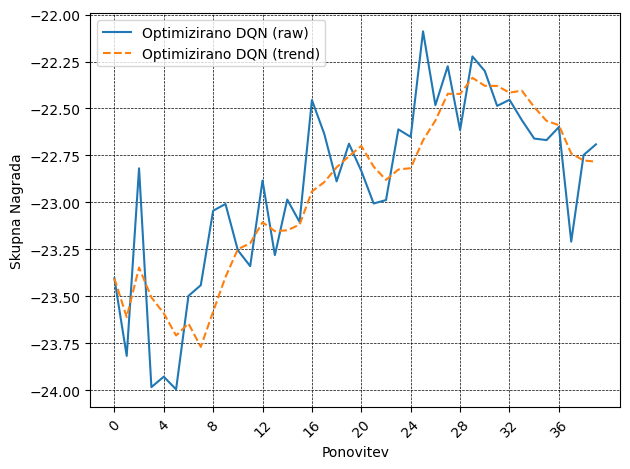

Zadnja raw nagrada: -22.69
Zadnja trend nagrada: -22.78


In [51]:
Y = [nagrada_seznam, nagrada_trend]
X = range(len(nagrada_seznam))
X_label = 'Ponovitev'
Y_label = 'Skupna Nagrada'
Legenda = ['Optimizirano DQN (raw)', 'Optimizirano DQN (trend)']
Naslov = 'Optimizacija preko 10 ponovitev DQN 2L 64 32N PC nagrada'
plotMultiY(X, Y, X_label, [Y_label], Legenda, Naslov, save_pdf=False)
print(f'Zadnja raw nagrada: {nagrada_seznam[-1]:.2f}')
print(f'Zadnja trend nagrada: {nagrada_trend[-1]:.2f}')

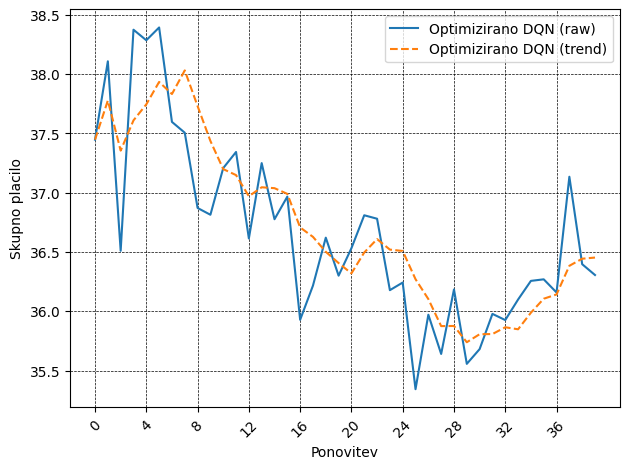

Zadnje raw placilo: 36.31
Zadnje trend placilo: 36.45


In [52]:
Y = [placilo_seznam, placilo_trend]
X = range(len(placilo_seznam))
X_label = 'Ponovitev'
Y_label = 'Skupno placilo'
Legenda = ['Optimizirano DQN (raw)', 'Optimizirano DQN (trend)']
Naslov = 'Optimizacija preko 10 ponovitev DQN 2L 64 32N PC placilo'
plotMultiY(X, Y, X_label, [Y_label], Legenda, Naslov, save_pdf=False)
print(f'Zadnje raw placilo: {placilo_seznam[-1]:.2f}')
print(f'Zadnje trend placilo: {placilo_trend[-1]:.2f}')

In [53]:
print(f'Nagrada po optimizaciji {nagradaDQN[-1]}')
print(f'Cena po optimizaciji {placiloDQN[-1]}')

Nagrada po optimizaciji -478.44014793937254
Cena po optimizaciji 765.5042367029912


#### Grafi DQN

###### Grafi DQN setup

In [54]:
sarsa_train_env = build_dqn_env(
    dataset=train_data,
    dataset_norm=train_data_norm,
    episode_length=len(train_data) - 1,
    reset_mode="deterministic",
    observation_mode="compact",
)

sarsa_test_env = build_dqn_env(
    dataset=test_data,
    dataset_norm=test_data_norm,
    episode_length=len(test_data) - 1,
    reset_mode="deterministic",
    observation_mode="compact",
)

In [55]:
agent_train = LinearFunctionSarsaAgent(sarsa_train_env)
agent_test = LinearFunctionSarsaAgent(sarsa_test_env)

theta_trening, agent_train = QL_trening_krajsi(agent_train, env=sarsa_train_env)
agent_test.train(1, theta_trening, 0, 0, 0, env=sarsa_test_env)
print(f'cena po optimizaciji {agent_test.Price[-1]}')

nakljucni_agent = LinearFunctionSarsaAgent(sarsa_test_env)
nakljucni_agent.train(1, None, 1, 0, 0, env=sarsa_test_env)
alternating_agent = LinearFunctionSarsaAgent(sarsa_test_env)
alternating_agent.train(1, None, 1, 0, 0, env=sarsa_test_env, alternating_actions=True)

epsilon_end_old = epsilon_end
epsilon_end = 1
nakljucni_nagradaDQN, nakljucni_placiloDQN, nakljucni_baterijaDQN, nakljucni_NagradaKapaciteta, nakljucni_NagradaSprememba, nakljucni_NagradaPlacilo = Learning_DQN(ucenje=False, random=True)
epsilon_end = epsilon_end_old

cena po optimizaciji 911.5872127214303
Random eval: epsilon = 1.0
Episode: 1
Steps per episode: 23295
Epsilon 1.0000
Final price: 1056.69 EUR


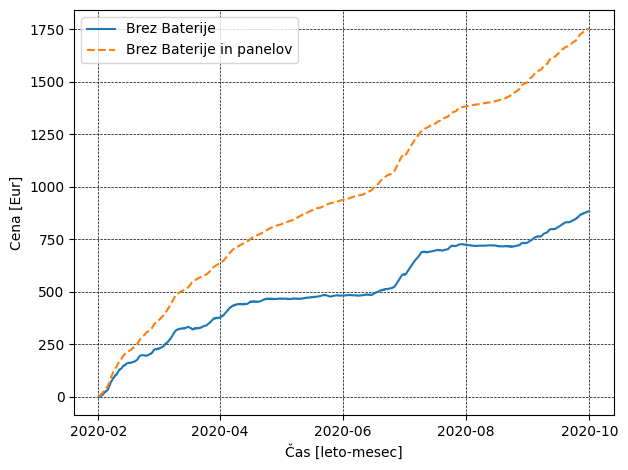

Placilo brez panelov 1753.6790324552626
Placilo brez baterije 883.3454941041344


In [56]:
cena = test_data["SMP"]
proizvodnja = test_data["Energy_Generation"]
poraba = test_data["Energy_Consumption"]
Placilo_brez_baterije_trenutno = 0
Placilo_brez_baterije_skupno = []
Placilo_brez_panelov_trenutno = 0
Placilo_brez_panelov_skupno = []
for i in range(len(test_data)):
    KupljenaElektrika = poraba.iloc[i] - proizvodnja.iloc[i]
    if KupljenaElektrika > 0:
        PlaciloZdaj =  cena.iloc[i]*KupljenaElektrika
    else:
        PlaciloZdaj =  cena.iloc[i]*KupljenaElektrika*faktor_cenitve     #predvidevamo da je cena prodane elektrike za foaktor cenitve nižja od cene kupljene elektrike
    Placilo_brez_baterije_trenutno += PlaciloZdaj
    Placilo_brez_baterije_skupno.append(Placilo_brez_baterije_trenutno)
    Placilo_brez_panelov_trenutno +=  poraba.iloc[i]*cena.iloc[i]
    Placilo_brez_panelov_skupno.append(Placilo_brez_panelov_trenutno)
#Placilo_brez_baterije_koncno = np.dot(poraba,cena) - np.dot(proizvodnja,cena)/4
#plt.plot(np.arange(len(poraba)),Placilo_brez_baterije_skupno)
#plt.plot(np.arange(len(poraba)),Placilo_brez_panelov_skupno)
Y = [Placilo_brez_baterije_skupno, Placilo_brez_panelov_skupno]
X = alternating_agent.Date
X_label = 'Čas [leto-mesec]'
Y_label = 'Cena [Eur]'
Legenda = ['Brez Baterije', 'Brez Baterije in panelov']
Naslov = 'Vpliv panelov na ceno elektrike pri odkupu po polovični ceni'
plotMultiY(X, Y, X_label, [Y_label],Legenda ,Naslov, save_pdf=False)
print(f"Placilo brez panelov {Placilo_brez_panelov_skupno[-1]}")
print(f"Placilo brez baterije {Placilo_brez_baterije_skupno[-1]}")

In [57]:
sarsa_no_battery_env = HouseholdEnvironment(
    dataset=test_data,
    dataset_norm=test_data_norm,
    observation_mode="compact",
    reset_mode="deterministic",
    episode_length=len(test_data) - 1,
    korakov_na_dan=KorakovNaDan,
    bat_kapaciteta=0,
    bat_ucinkovitost=BatUcinkovitost,
    bat_max_polnjenje=BatMaxPolnjenje,
    bat_max_praznjenje=BatMaxPraznjenje,
    faktor_cenitve=faktor_cenitve,
    faktor_n1=faktorN1,
    faktor_n2=faktorN2,
    faktor_n3=faktorN3,
 )

agent_brez_baterije = LinearFunctionSarsaAgent(sarsa_no_battery_env)
agent_brez_baterije.train(1, None, 1, 0, 0, env=sarsa_no_battery_env)

array([0., 0., 0., ..., 0., 0., 0.], shape=(40000,))

###### Grafi DQN analiza poskusa

In [98]:
save_pdf = False
save_png = False
print(f'BatUcinkovitost: {BatUcinkovitost}')
print(f'faktor_cenitve: {faktor_cenitve}')
print(f'BatKapaciteta: {BatKapaciteta}')
print(f'faktorN1: {faktorN1}')
print(f'faktorN2: {faktorN2}')
print(f'faktorN3: {faktorN3}')
print(f'faktor_cenitve: {faktor_cenitve}')
print(f'Nagrada po optimizaciji {nagradaDQN[-1]}')
print(f'Cena po optimizaciji DQN {placiloDQN[-1]}')
print(f'gamma: {gamma} ')
print(f'lr: {lr} ')
print(f'epsilon_start: {epsilon_start} ')
print(f'epsilon_end: {epsilon_end} ')
print(f'epsilon_decay: {epsilon_decay} ')
print(f'batch_size: {batch_size} ')
print(f'fc1_dims: {fc1_dims} ')
print(f'fc2_dims: {fc2_dims} ')
print(f'fc3_dims: {fc3_dims} ')
print(f'replace_target: {replace_target} ')
print(f'weight_decay: {weight_decay} ')

BatUcinkovitost: 0.95
faktor_cenitve: 0.6666666666666666
BatKapaciteta: 20
faktorN1: 0
faktorN2: 0
faktorN3: 1
faktor_cenitve: 0.6666666666666666
Nagrada po optimizaciji -478.44014793937254
Cena po optimizaciji DQN 765.5042367029912
gamma: 0.9857302559125477 
lr: 1.1584493457792702e-05 
epsilon_start: 0.8737665045005893 
epsilon_end: 0.016776902971714826 
epsilon_decay: 3.44354532885725e-05 
batch_size: 96 
fc1_dims: 512 
fc2_dims: 256 
fc3_dims: 64 
replace_target: 901 
weight_decay: 0.0003022167240849796 


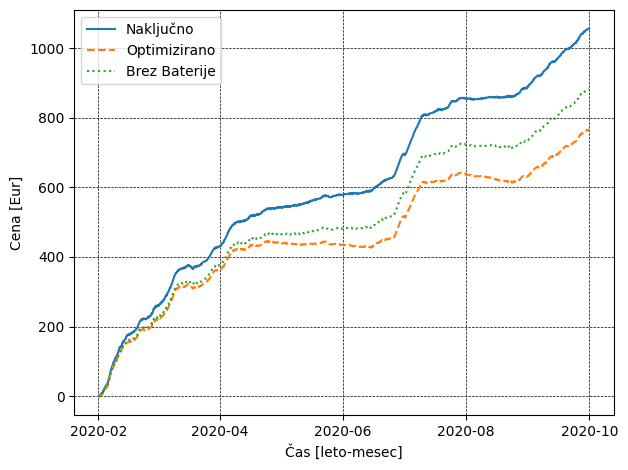

Placilo po optimizaciji 765.5042367029912
Placilo brez baterije 883.2388741041344


In [87]:
# CELL 60: Graf primerjave cen po različnih metodah
Y = [nakljucni_placiloDQN[:-1], placiloDQN[:-1], agent_brez_baterije.Price[:-1]] #, alternating_agent.Price ,  nakljucni_agent.Price
# Y = [nakljucni_agent.Price, placiloDQN, agent_brez_baterije.Price] #, alternating_agent.Price
X = nakljucni_agent.Date
X_label = 'Čas [leto-mesec]'
Y_label = 'Cena [Eur]'
Legenda = ['Naključno','Optimizirano','Brez Baterije', 'Naključno DQN']  # ,'Zaporedno'
Naslov = 'Cena elektrike v drugi polovici podatkov DQN 1L 16N P'
# plotMultiY(X, Y, X_label, [Y_label],Legenda ,Naslov, save_pdf = False)
plotMultiY(X, Y, X_label, [Y_label],Legenda ,Naslov, save_pdf = save_pdf, save = save_png)
print(f'Placilo po optimizaciji {placiloDQN[-1]}')
print(f'Placilo brez baterije {agent_brez_baterije.Price[-1]}')

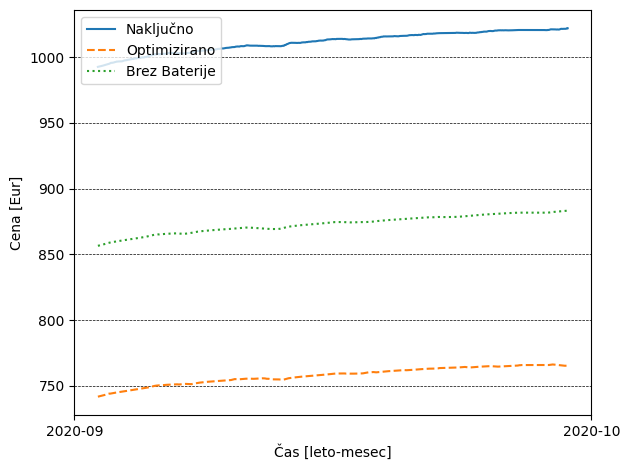

Placilo po optimizaciji 765.5042367029912
Placilo brez baterije 883.2388741041344


In [88]:
# CELL 61: Graf primerjave cen po različnih metodah - zadnjih 5000 korakov
last_points = 500
Y = [nakljucni_agent.Price[-last_points:], placiloDQN[-(last_points+1):-1], agent_brez_baterije.Price[-last_points:]]
X = nakljucni_agent.Date[-last_points:]
X_label = 'Čas [leto-mesec]'
Y_label = 'Cena [Eur]'
Legenda = ['Naključno','Optimizirano','Brez Baterije']
Naslov = 'Cena elektrike v zadnjih 300 korakih DQN 1L 16N P'
plotMultiY(X, Y, X_label, [Y_label],Legenda ,Naslov, save_pdf = save_pdf, save = save_png)
print(f'Placilo po optimizaciji {placiloDQN[-1]}')
print(f'Placilo brez baterije {agent_brez_baterije.Price[-1]}')

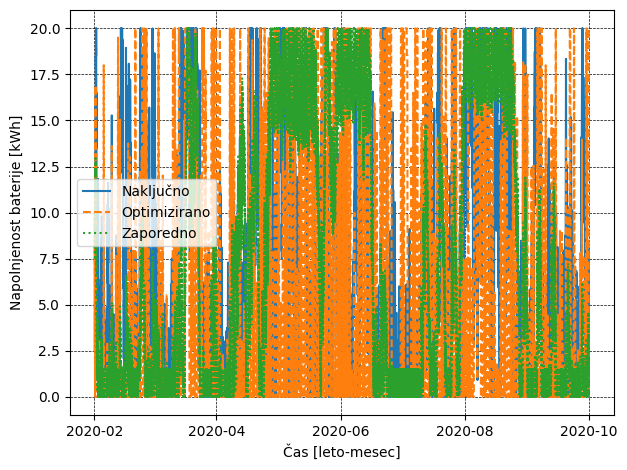

In [89]:
### CELL 62: Primerjava stanja baterije
Y = [nakljucni_agent.NapolnjenostBaterije, baterijaDQN, alternating_agent.NapolnjenostBaterije]
X = alternating_agent.Date
X_label = 'Čas [leto-mesec]'
Y_label = 'Napolnjenost baterije [kWh]'
Legenda = ['Naključno','Optimizirano','Zaporedno']
Naslov = 'Napolnjenost baterije sistem Q spodbujevalnega učenja DQN'
plotMultiY(X, Y, X_label, [Y_label],Legenda ,Naslov, save_pdf = save_pdf, save = save_png)
# plotMultiY(X, Y, X_label, [Y_label],Legenda ,Naslov, save_pdf = True)

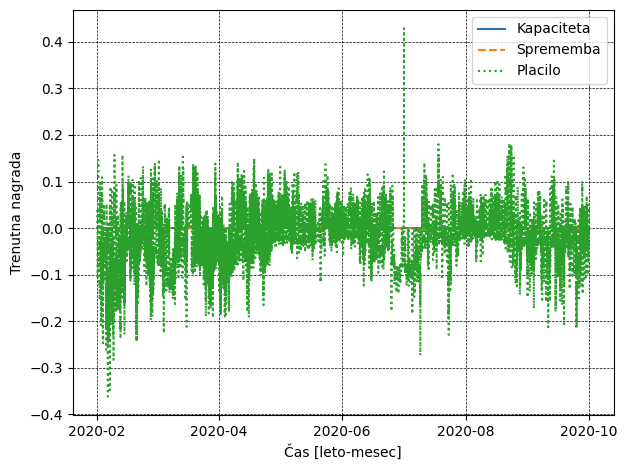

In [90]:
### CELL 63: Primerjava različnih komponent nagrade
Y = [NagradaKapaciteta, NagradaSprememba, NagradaPlacilo]
X = alternating_agent.Date
X_label = 'Čas [leto-mesec]'
Y_label = 'Trenutna nagrada'
Legenda = ['Kapaciteta','Sprememba','Placilo']
Naslov = 'Velikosti nagrad v danem trenutku 1L 16N P'
# plotMultiY(X, Y, X_label, [Y_label],Legenda ,Naslov, save_pdf = False)
plotMultiY(X, Y, X_label, [Y_label],Legenda ,Naslov, save_pdf = save_pdf, save = save_png)

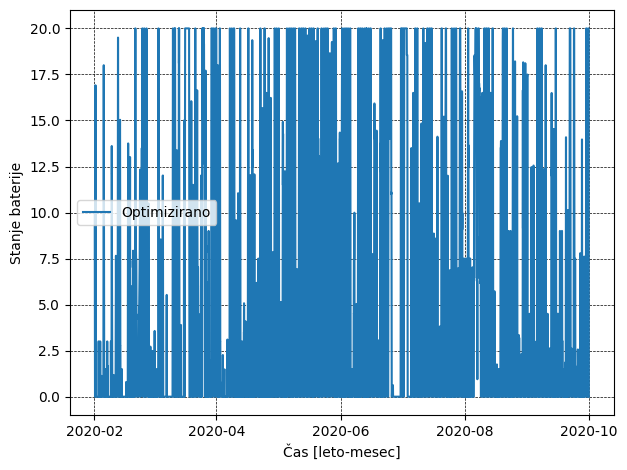

In [91]:
### CELL 64: Ogled stanja baterije
Y = [baterijaDQN]
X = alternating_agent.Date
X_label = 'Čas [leto-mesec]'
Y_label = 'Stanje baterije'
Legenda = ['Optimizirano']
Naslov = 'Proporcionalna napolnjenost baterije optimizirano DQN'
plotMultiY(X, Y, X_label, [Y_label],Legenda ,Naslov, save_pdf = save_pdf, save = save_png)

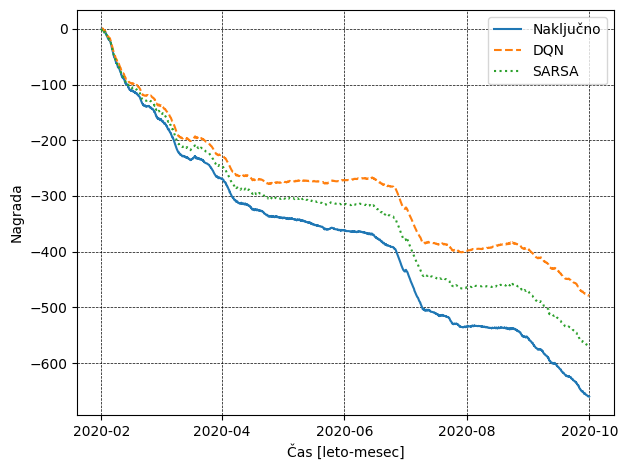

-569.7420079508995


In [92]:
### CELL 65: Primerjava skupne nagrade po različnih metodah

#plt.plot(range(len(agent_test.NagradaSkupno)),  nakljucni_agent.NagradaSkupno, 'r')
#plt.plot(range(len(agent_test.NagradaSkupno)), agent_test.NagradaSkupno, 'b')
# nakljucni_agent_NagradaSkupno = np.array(nakljucni_agent.NagradaSkupno)/1
alternating_agent_NagradaSkupno = np.array(alternating_agent.NagradaSkupno)/1
Y = [nakljucni_nagradaDQN, nagradaDQN, agent_test.NagradaSkupno]
X = nakljucni_agent.Date
X_label = 'Čas [leto-mesec]'
Y_label = 'Nagrada'
Legenda = ['Naključno','DQN','SARSA']
Naslov = 'Primerjava nagrad SARSA in DQN'
plotMultiY(X, Y, X_label, [Y_label],Legenda ,Naslov, save_pdf = save_pdf, save = save_png)
print(agent_test.NagradaSkupno[-1])

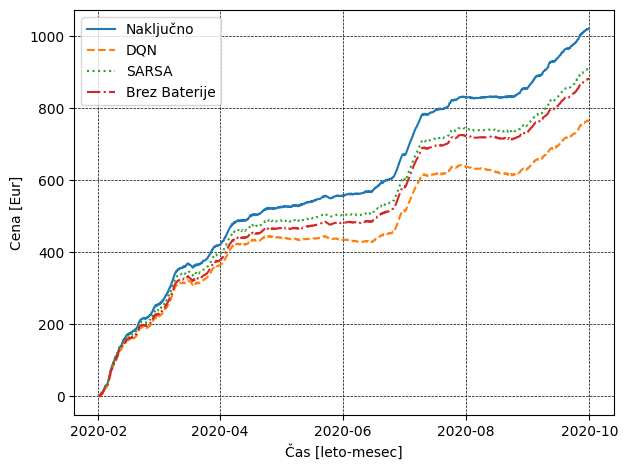

Končna cena po drugi polovici podatkov SARSA 911.5872127214303
Končna cena po drugi polovici podatkov DEQN 765.5042367029912
Končna cena po drugi polovici podatkov brez bateije 883.2388741041344
Končna cena po drugi polovici podatkov naključno 1021.8206528045466
Končna cena po drugi polovici podatkov zaporedno 1023.5891684479606


In [93]:
#### CELL 66: Primerjava skupnega plačila po različnih metodah
Y = [nakljucni_agent.Price, placiloDQN[:-1], agent_test.Price, agent_brez_baterije.Price]
# Y = [nakljucni_agent.Price, agent_test.Price, agent_brez_baterije.Price]
X = alternating_agent.Date
X_label = 'Čas [leto-mesec]'
Y_label = 'Cena [Eur]'
Legenda = ['Naključno','DQN','SARSA','Brez Baterije']
# Legenda = ['Naključno','Optimizirano','Brez Baterije']
Naslov = 'Primarjava placila SARSA in DQN'
plotMultiY(X, Y, X_label, [Y_label],Legenda ,Naslov, save_pdf = save_pdf, save = save_png)

print(f"Končna cena po drugi polovici podatkov SARSA {agent_test.Price[-1]}")
print(f"Končna cena po drugi polovici podatkov DEQN {placiloDQN[-1]}")
print(f"Končna cena po drugi polovici podatkov brez bateije {agent_brez_baterije.Price[-1]}")
print(f"Končna cena po drugi polovici podatkov naključno {nakljucni_agent.Price[-1]}")
print(f"Končna cena po drugi polovici podatkov zaporedno {alternating_agent.Price[-1]}")

## Optional Stable-Baselines3 benchmark

Use these cells only when you want an SB3 comparison against the current custom workflow. The default notebook path stays unchanged.

In [114]:
# ============================================================
# SB3 Benchmark Configuration & Setup
# ============================================================

import importlib
import Environment as environment_module
import sb3_runner as sb3_runner_module
import optuna_sb3_tuner as optuna_sb3_tuner_module

importlib.reload(sb3_runner_module)
importlib.reload(optuna_sb3_tuner_module)

HouseholdEnvironment = environment_module.HouseholdEnvironment
run_sb3_benchmark = sb3_runner_module.run_sb3_benchmark
create_comparison_table = sb3_runner_module.create_comparison_table
run_optimization_for_algorithms = optuna_sb3_tuner_module.run_optimization_for_algorithms

# Configuration flags
RUN_SB3_BENCHMARK = True
RUN_SB3_OPTIMIZATION = False  # Set to True to enable Optuna hyperparameter tuning

# Trial-run parameters
SB3_TOTAL_TIMESTEPS = 60000
SB3_N_SEEDS = 3
SB3_N_EVAL_EPISODES = 10
SB3_ALGORITHMS = ["DQN", "PPO", "A2C", "QR_DQN", "MASKABLE_PPO", "RECURRENT_PPO"]
SB3_EPISODE_STEPS = KorakovNaDan * 7

# Output directory
SB3_OUTPUT_DIR = "SB3"


def build_sb3_env(dataset, dataset_norm, reset_mode):
    return HouseholdEnvironment(
        dataset=dataset,
        dataset_norm=dataset_norm,
        observation_mode="sliding_window",
        reset_mode=reset_mode,
        episode_length=min(len(dataset) - 1, SB3_EPISODE_STEPS),
        korakov_na_dan=KorakovNaDan,
        bat_kapaciteta=BatKapaciteta,
        bat_ucinkovitost=BatUcinkovitost,
        bat_max_polnjenje=BatMaxPolnjenje,
        bat_max_praznjenje=BatMaxPraznjenje,
        faktor_cenitve=faktor_cenitve,
        faktor_n1=faktorN1,
        faktor_n2=faktorN2,
        faktor_n3=faktorN3,
    )


sb3_train_env = build_sb3_env(train_data, train_data_norm, reset_mode="random")
sb3_eval_env = build_sb3_env(test_data, test_data_norm, reset_mode="sequential")

print("SB3 Benchmark Configuration:")
print(f"  Optimization: {'ENABLED' if RUN_SB3_OPTIMIZATION else 'DISABLED'}")
print(f"  Algorithms: {', '.join(SB3_ALGORITHMS)}")
print(f"  Seeds per algorithm: {SB3_N_SEEDS}")
print(f"  Total timesteps: {SB3_TOTAL_TIMESTEPS}")
print(f"  Episode length: {SB3_EPISODE_STEPS}")
print(f"  Output directory: {SB3_OUTPUT_DIR}")
print(f"  sb3-contrib available: {sb3_runner_module.SB3_CONTRIB_AVAILABLE}")

SB3 Benchmark Configuration:
  Optimization: DISABLED
  Algorithms: DQN, PPO, A2C, QR_DQN, MASKABLE_PPO, RECURRENT_PPO
  Seeds per algorithm: 3
  Total timesteps: 60000
  Episode length: 672
  Output directory: SB3
  sb3-contrib available: True


In [115]:
# ============================================================
# Run SB3 Benchmark with Optional Optimization
# ============================================================

if RUN_SB3_BENCHMARK:
    print("\n" + "=" * 80)
    print("STARTING SB3 BENCHMARK")
    print("=" * 80 + "\n")

    # Step 1: Optional - Run Optuna optimization for each algorithm
    if RUN_SB3_OPTIMIZATION:
        print("Step 1: Hyperparameter Optimization with Optuna")
        print("-" * 80)
        optuna_results = run_optimization_for_algorithms(
            algorithms=SB3_ALGORITHMS,
            env=sb3_train_env,
            eval_env=sb3_eval_env,
            n_trials=20,
            output_dir=SB3_OUTPUT_DIR,
            verbose=0,
        )
        print("\nOptimization complete")
    else:
        print("Step 1: Optimization skipped (RUN_SB3_OPTIMIZATION=False)")
        print("-" * 80)
        optuna_results = None

    # Step 2: Multi-seed training and evaluation
    print("\nStep 2: Multi-seed training and evaluation")
    print("-" * 80)
    sb3_results = run_sb3_benchmark(
        train_env=sb3_train_env,
        eval_env=sb3_eval_env,
        test_env=sb3_eval_env,
        algorithms=SB3_ALGORITHMS,
        total_timesteps=SB3_TOTAL_TIMESTEPS,
        n_seeds=SB3_N_SEEDS,
        n_eval_episodes=SB3_N_EVAL_EPISODES,
        output_dir=SB3_OUTPUT_DIR,
        verbose=0,
    )
    print("\nTraining complete")

    # Step 3: Create comparison table
    print("\nStep 3: Build comparison table")
    print("-" * 80)
    baseline_dict = None
    if "baseline_summary" in globals():
        baseline_dict = {
            "reward_mean": baseline_summary.get("reward_mean", 0.0),
            "reward_std": baseline_summary.get("reward_std", 0.0),
            "price_mean": baseline_summary.get("price_mean", 0.0),
            "price_std": baseline_summary.get("price_std", 0.0),
        }

    sb3_comparison_table = create_comparison_table(
        sb3_results,
        baseline_results=baseline_dict,
    )

    print("\n" + sb3_comparison_table.to_string(index=False))
    print("\n" + "=" * 80)
    print("BENCHMARK COMPLETE")
    print("=" * 80)
else:
    print("SB3 benchmark skipped. Set RUN_SB3_BENCHMARK = True to enable.")


STARTING SB3 BENCHMARK

Step 1: Optimization skipped (RUN_SB3_OPTIMIZATION=False)
--------------------------------------------------------------------------------

Step 2: Multi-seed training and evaluation
--------------------------------------------------------------------------------

SB3 Benchmark: 6 algorithms × 3 seeds


────────────────────────────────────────────────────────────
Training DQN
────────────────────────────────────────────────────────────
  Seed 11... 

KeyboardInterrupt: 

# BTR (Beyond the Rainbow) Algorithm Implementation

This section demonstrates training and comparing Beyond the Rainbow (BTR) DQN variants (IQN and C51) on the household energy management environment.

BTR combines multiple deep RL enhancements:
- **IQN**: Implicit Quantile Networks - distributional RL with flexible value distributions
- **C51**: Categorical DQN - distributional RL with fixed-support atoms
- **PER**: Prioritized Experience Replay for efficient learning
- **Noisy Networks**: Exploration via parameter noise
- **Spectral Normalization**: Training stability
- **Munchausen Addon**: Enhanced reward estimation

Toggle optimization on/off, save best agents, and compare with SB3 algorithms.

In [ ]:
# Import BTR modules
import importlib
import torch
import btr_runner as btr_runner_module
import btr_comparison as btr_comparison_module
import btr_quickstart as btr_quickstart_module

importlib.reload(btr_runner_module)
importlib.reload(btr_comparison_module)
importlib.reload(btr_quickstart_module)

from btr_runner import BTRTrainer, run_btr_benchmark
from btr_comparison import BTRComparison
from btr_quickstart import (
    quickstart_single_seed_training,
    quickstart_multi_seed_benchmark,
    quickstart_comparison,
)

# Configuration for BTR training
BTR_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BTR_OUTPUT_DIR = "BTR"
BTR_TOTAL_TIMESTEPS = 100000  # Adjust based on compute budget
BTR_N_SEEDS = 3
BTR_N_EVAL_EPISODES = 10
BTR_EVAL_FREQ = 5000
BTR_ALGORITHMS = ["IQN", "C51"]
BTR_USE_OPTUNA = False  # Set to True to enable hyperparameter optimization
BTR_N_OPTUNA_TRIALS = 3  # Number of Optuna trials (only if BTR_USE_OPTUNA=True)

print(f"BTR Configuration:")
print(f"  Device: {BTR_DEVICE}")
print(f"  Output Directory: {BTR_OUTPUT_DIR}")
print(f"  Total Timesteps (per seed): {BTR_TOTAL_TIMESTEPS}")
print(f"  Number of Seeds: {BTR_N_SEEDS}")
print(f"  Algorithms: {BTR_ALGORITHMS}")
print(f"  Use Optuna: {BTR_USE_OPTUNA}")

BTR Configuration:
  Device: cpu
  Output Directory: BTR
  Total Timesteps (per seed): 3000
  Number of Seeds: 1
  Algorithms: ['IQN', 'C51']
  Use Optuna: False


## Single-Seed BTR Training (Quick Test)

Train a single IQN agent to verify setup works. Use this to test hyperparameters before full multi-seed run.

In [69]:
# Option 1: Quick single-seed test (IQN)
RUN_BTR_QUICK_TEST = True  # Set to True to run

if RUN_BTR_QUICK_TEST:
    print("Running quick BTR test (IQN, 1 seed, short training)...")

    # Create train/eval environments with limited data for speed
    btr_train_env = HouseholdEnvironment(
        dataset=train_data[:len(train_data)//2],
        dataset_norm=train_data_norm[:len(train_data_norm)//2],
        observation_mode="compact",
        episode_length=1000,
    )

    btr_eval_env = HouseholdEnvironment(
        dataset=test_data[:len(test_data)//2],
        dataset_norm=test_data_norm[:len(test_data_norm)//2],
        observation_mode="compact",
        episode_length=1000,
    )

    # Train single IQN agent
    iqn_metrics = quickstart_single_seed_training(
        train_env=btr_train_env,
        eval_env=btr_eval_env,
        algorithm="IQN",
        total_timesteps=20000,  # Quick test: short training
        use_optuna=False,
        device=BTR_DEVICE,
        verbose=1,
    )

    print("\n✓ Quick test completed!")
    print(f"  Reward: {iqn_metrics['reward_mean']:.2f}")
    print(f"  Energy Cost: {iqn_metrics['price_mean']:.2f}")
else:
    print("Quick BTR test SKIPPED. Set RUN_BTR_QUICK_TEST=True to run.")

Running quick BTR test (IQN, 1 seed, short training)...

BTR Quick Start - Single Seed Training (IQN)
[IQN@seed=42] Timesteps: 2000/20000 | Reward: -39.86 | Price: 127.63
[IQN@seed=42] Timesteps: 4000/20000 | Reward: -39.86 | Price: 127.63
[IQN@seed=42] Timesteps: 6000/20000 | Reward: -40.38 | Price: 130.29
[IQN@seed=42] Timesteps: 8000/20000 | Reward: -40.38 | Price: 129.21
[IQN@seed=42] Timesteps: 10000/20000 | Reward: -39.86 | Price: 127.63
[IQN@seed=42] Timesteps: 12000/20000 | Reward: -40.38 | Price: 129.21
[IQN@seed=42] Timesteps: 14000/20000 | Reward: -40.38 | Price: 129.21
[IQN@seed=42] Timesteps: 16000/20000 | Reward: -40.38 | Price: 129.21
[IQN@seed=42] Timesteps: 18000/20000 | Reward: -40.38 | Price: 129.21
[IQN@seed=42] Timesteps: 20000/20000 | Reward: -40.38 | Price: 129.21

✓ Training successful!
  Reward: -40.22 ± 0.24
  Energy Cost: 128.84 ± 0.85
  Model saved to: quickstart_IQN_model.pt

✓ Quick test completed!
  Reward: -40.22
  Energy Cost: 128.84


## Multi-Seed BTR Benchmark (IQN vs C51)

Run full multi-seed benchmark comparing IQN and C51 variants. This will train both algorithms across multiple seeds and aggregate statistics. Toggle optimization to search hyperparameters using Optuna or grid search.

In [109]:
# Option 2: Full multi-seed benchmark
RUN_BTR_BENCHMARK = True  # Set to True to run full benchmark

if RUN_BTR_BENCHMARK:
    print("="*70)
    print("Running BTR Multi-Seed Benchmark (IQN vs C51)")
    print("="*70)

    # Create train/eval/test environments
    btr_train_env = HouseholdEnvironment(
        dataset=train_data,
        dataset_norm=train_data_norm,
        observation_mode="compact",
    )

    btr_eval_env = HouseholdEnvironment(
        dataset=test_data[:len(test_data)//2],
        dataset_norm=test_data_norm[:len(test_data_norm)//2],
        observation_mode="compact",
    )

    btr_test_env = HouseholdEnvironment(
        dataset=test_data[len(test_data)//2:],
        dataset_norm=test_data_norm[len(test_data_norm)//2:],
        observation_mode="compact",
    )

    # Run benchmark
    btr_results = run_btr_benchmark(
        train_env=btr_train_env,
        eval_env=btr_eval_env,
        test_env=btr_test_env,
        algorithms=BTR_ALGORITHMS,
        total_timesteps=BTR_TOTAL_TIMESTEPS,
        n_seeds=BTR_N_SEEDS,
        n_eval_episodes=BTR_N_EVAL_EPISODES,
        eval_freq=BTR_EVAL_FREQ,
        output_dir=BTR_OUTPUT_DIR,
        device=BTR_DEVICE,
        use_optuna=BTR_USE_OPTUNA,
        n_optuna_trials=BTR_N_OPTUNA_TRIALS,
        verbose=1,
    )

    print("\n" + "="*70)
    print("BTR Benchmark Results")
    print("="*70)
    for algo, metrics in btr_results.items():
        print(f"\n{algo}:")
        print(f"  Reward: {metrics['reward_mean']:.2f} ± {metrics['reward_std']:.2f}")
        print(f"  Energy Cost: {metrics['price_mean']:.2f} ± {metrics['price_std']:.2f}")

else:
    print("BTR Multi-Seed Benchmark SKIPPED. Set RUN_BTR_BENCHMARK=True to run.")

Running BTR Multi-Seed Benchmark (IQN vs C51)

Training IQN - Seed 1/1
[IQN@seed=0] Timesteps: 1000/3000 | Reward: -149.93 | Price: 479.87
[IQN@seed=0] Timesteps: 2000/3000 | Reward: -150.45 | Price: 481.45
[IQN@seed=0] Timesteps: 3000/3000 | Reward: -151.08 | Price: 483.37

Training C51 - Seed 1/1
[C51@seed=0] Timesteps: 1000/3000 | Reward: -119.50 | Price: 482.93
[C51@seed=0] Timesteps: 2000/3000 | Reward: -151.08 | Price: 483.37
[C51@seed=0] Timesteps: 3000/3000 | Reward: -151.08 | Price: 483.37

BTR Benchmark Summary

IQN:
  Reward: -126.17 ± 0.00
  Price:  402.30 ± 0.00
  Quick 7D Price: -0.18

C51:
  Reward: -126.17 ± 0.00
  Price:  402.30 ± 0.00
  Quick 7D Price: -0.18

Results saved to: BTR

BTR Benchmark Results

IQN:
  Reward: -126.17 ± 0.00
  Energy Cost: 402.30 ± 0.00

C51:
  Reward: -126.17 ± 0.00
  Energy Cost: 402.30 ± 0.00


## BTR vs SB3 Comparison

Compare BTR algorithms (IQN, C51) with existing SB3 algorithms (DQN, PPO, etc.).
Generate comparison tables, identify best agent, and visualize trade-offs.

In [71]:
# Load and compare BTR with SB3 results
from btr_comparison import BTRComparison

print("Loading BTR and SB3 results for comparison...")

comparator = BTRComparison(
    btr_results_dir=BTR_OUTPUT_DIR,
    sb3_results_dir=SB3_OUTPUT_DIR,
)

# Load BTR results
btr_data = comparator.load_btr_results()
if btr_data is not None:
    print("\n✓ BTR Results Loaded:")
    print(f"  Shape: {btr_data.shape}")
    print(f"  Algorithms: {btr_data['algorithm'].unique().tolist()}")
else:
    print("\n✗ No BTR results found. Run BTR benchmark first.")

# Load SB3 results
sb3_data = comparator.load_sb3_results()
if sb3_data is not None:
    print("\n✓ SB3 Results Loaded:")
    print(f"  Shape: {sb3_data.shape}")
    print(f"  Algorithms: {sb3_data['algorithm'].unique().tolist()}")
else:
    print("\n✗ No SB3 results found.")

# Within-BTR comparison
if btr_data is not None:
    print("\n" + "="*70)
    print("Within-BTR Comparison (IQN vs C51)")
    print("="*70)
    btr_comp = comparator.compare_within_btr()
    if btr_comp is not None:
        print(btr_comp.to_string(index=False))

# BTR vs SB3 comparison
if btr_data is not None and sb3_data is not None:
    print("\n" + "="*70)
    print("BTR vs SB3 Comparison")
    print("="*70)
    combined = comparator.compare_btr_vs_sb3()
    if combined is not None:
        print(combined.to_string(index=False))

        # Show best agent
        best = comparator.get_best_agent()
        if best:
            print("\n✓ Best Agent (by energy cost):")
            print(f"  Algorithm: {best['algorithm']}")
            print(f"  Seed: {best['seed']}")
            print(f"  Energy Cost: {best['price_mean']:.2f} EUR")
            print(f"  Reward: {best['reward_mean']:.2f}")
            print(f"  Model: {best.get('model_path', 'N/A')}")

    # Generate report
    print("\nGenerating comparison report...")
    report_path = os.path.join(BTR_OUTPUT_DIR, "comparison_report.md")
    comparator.generate_comparison_report(output_path=report_path)
    print(f"Report saved to: {report_path}")

    # Save best agent info
    best_path = os.path.join(BTR_OUTPUT_DIR, "best_agent/summary.json")
    comparator.save_best_agent_info(output_path=best_path)
else:
    print("\nSkipping comparison (need both BTR and SB3 results)")

Loading BTR and SB3 results for comparison...

✓ BTR Results Loaded:
  Shape: (6, 7)
  Algorithms: ['IQN', 'C51']

✗ No SB3 results found.

Within-BTR Comparison (IQN vs C51)
algorithm  n_seeds  reward_mean  reward_std  price_mean  price_std  best_price  worst_price  price_range
      C51        3  -144.961127    8.150729  479.953407   2.105451  477.523176   481.226862     3.703686
      IQN        3  -150.705570    0.645993  482.229993   1.977657  479.946391   483.371793     3.425403

Skipping comparison (need both BTR and SB3 results)


## BTR Visualization and Analysis

Plot comparison graphs, training progress, and algorithm rankings.

Generating BTR-only visualization plots...

Plot 1: BTR Algorithm Comparison (IQN vs C51)


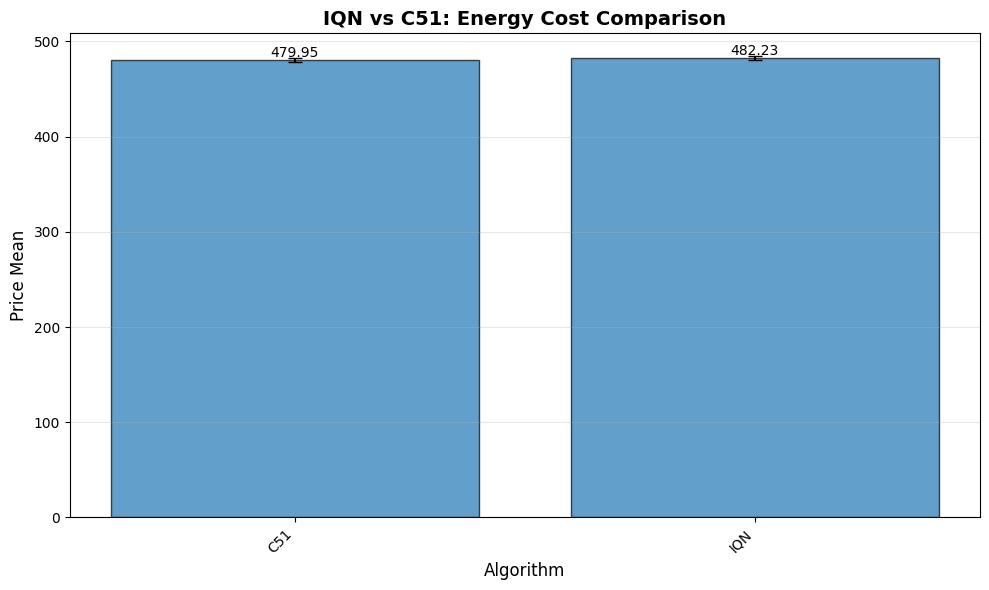

Plot 2: Energy Cost Distribution


/Users/tomaz/Documents/Andraz/Household-RL/Ploting_Functions.py:208: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="algorithm", y="price_mean", ax=ax, palette="Set2")
/Users/tomaz/Documents/Andraz/Household-RL/Ploting_Functions.py:209: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="algorithm", y="price_mean", ax=ax, width=0.3, palette="Set2")


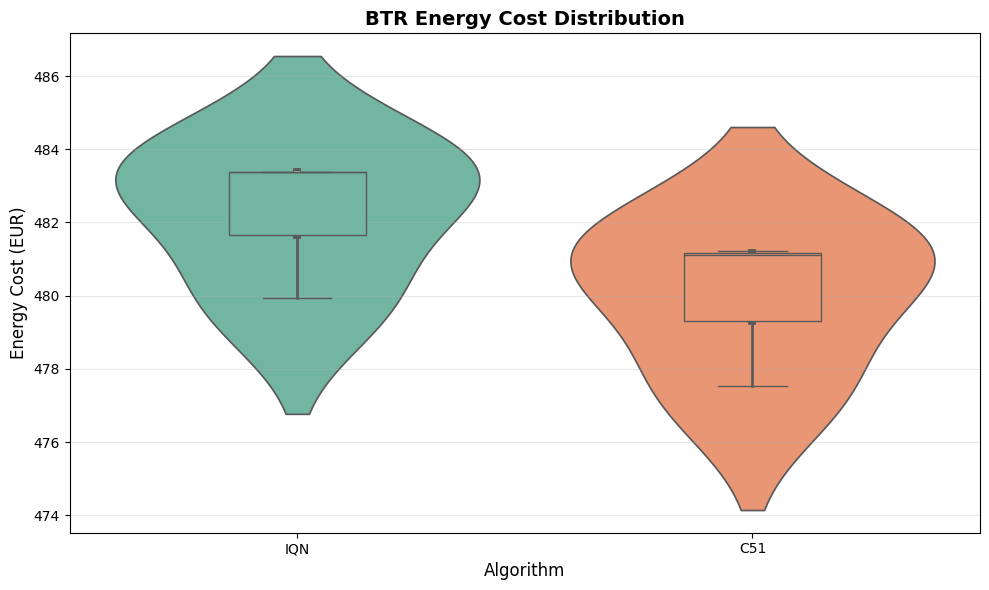


✓ BTR plots generated!


In [96]:
# Import plotting functions
from Ploting_Functions import (
    plot_btr_comparison,
    plot_training_progress,
    plot_price_distribution,
    plot_reward_vs_price,
    plot_algorithm_ranking,
)

if btr_data is not None and sb3_data is not None:
    print("Generating BTR visualization plots...\n")

    # 1. Algorithm comparison (within BTR and vs SB3)
    combined = comparator.compare_btr_vs_sb3()
    print("Plot 1: Algorithm Comparison (Energy Cost)")
    plot_btr_comparison(
        combined,
        metric="price_mean",
        title="BTR vs SB3: Energy Cost Comparison",
        save=True
    )

    # 2. Price distribution across seeds
    print("Plot 2: Energy Cost Distribution")
    plot_price_distribution(
        btr_data,
        algorithm_filter=None,
        title="BTR Energy Cost Distribution (Violin Plot)",
        save=True
    )

    # 3. Reward vs Price trade-off
    print("Plot 3: Reward vs Energy Cost Trade-off")
    if "reward_mean" in combined.columns:
        plot_reward_vs_price(
            combined,
            title="Algorithm Trade-off: Reward vs Energy Cost",
            save=True
        )

    # 4. Algorithm ranking by energy cost
    print("Plot 4: Algorithm Ranking")
    plot_algorithm_ranking(
        combined,
        metric="price_mean",
        ascending=True,
        title="Algorithm Ranking by Energy Cost (Lower is Better)",
        save=True
    )

    print("\n✓ All plots generated and saved!")

elif btr_data is not None:
    print("Generating BTR-only visualization plots...\n")

    # Within-BTR comparison
    btr_comp = comparator.compare_within_btr()
    print("Plot 1: BTR Algorithm Comparison (IQN vs C51)")
    plot_btr_comparison(
        btr_comp,
        metric="price_mean",
        title="IQN vs C51: Energy Cost Comparison",
        save=True
    )

    # Price distribution
    print("Plot 2: Energy Cost Distribution")
    plot_price_distribution(
        btr_data,
        title="BTR Energy Cost Distribution",
        save=True
    )

    print("\n✓ BTR plots generated!")

else:
    print("No data available for plotting. Run BTR benchmark first.")

## Detailed Algorithm Statistics

Print detailed per-algorithm statistics for BTR variants.

In [73]:
if btr_data is not None:
    print("="*80)
    print("BTR ALGORITHM STATISTICS")
    print("="*80)

    for algo in sorted(btr_data["algorithm"].unique()):
        stats = comparator.get_algorithm_statistics(algo)
        if stats:
            print(f"\n{algo}:")
            print(f"  Seeds Trained: {stats['n_seeds']}")
            print(f"\n  Reward Statistics:")
            print(f"    Mean:  {stats['reward_mean']:>8.2f}")
            print(f"    Std:   {stats['reward_std']:>8.2f}")
            print(f"    Min:   {stats['reward_min']:>8.2f}")
            print(f"    Max:   {stats['reward_max']:>8.2f}")
            print(f"\n  Energy Cost Statistics (EUR):")
            print(f"    Mean:  {stats['price_mean']:>8.2f}")
            print(f"    Std:   {stats['price_std']:>8.2f}")
            print(f"    Min:   {stats['price_min']:>8.2f} (best)")
            print(f"    Max:   {stats['price_max']:>8.2f} (worst)")

            # Compute stability metric (low std = more stable)
            stability = 100 * (1 - stats['price_std'] / (stats['price_max'] - stats['price_min'] + 1e-6))
            print(f"    Stability Score: {stability:.1f}% (higher = more consistent)")

    print("\n" + "="*80)

else:
    print("No BTR results available for statistics.")

BTR ALGORITHM STATISTICS

C51:
  Seeds Trained: 3

  Reward Statistics:
    Mean:   -144.96
    Std:       8.15
    Min:    -150.35
    Max:    -135.58

  Energy Cost Statistics (EUR):
    Mean:    479.95
    Std:       2.11
    Min:     477.52 (best)
    Max:     481.23 (worst)
    Stability Score: 43.2% (higher = more consistent)

IQN:
  Seeds Trained: 3

  Reward Statistics:
    Mean:   -150.71
    Std:       0.65
    Min:    -151.08
    Max:    -149.96

  Energy Cost Statistics (EUR):
    Mean:    482.23
    Std:       1.98
    Min:     479.95 (best)
    Max:     483.37 (worst)
    Stability Score: 42.3% (higher = more consistent)



## Summary: BTR Implementation Complete

### ✓ What You Can Now Do:

1. **Single-Seed Training**: Quick test of IQN or C51 agents with `RUN_BTR_QUICK_TEST=True`

2. **Multi-Seed Benchmark**: Full training of IQN and C51 across N seeds with `RUN_BTR_BENCHMARK=True`
   - Trains agents on household energy management task
   - Evaluates every eval_freq steps
   - Saves best models and metrics

3. **Hyperparameter Optimization**: Toggle `BTR_USE_OPTUNA=True` to:
   - Use Optuna to search hyperparameter space (learning rate, batch size, quantiles, etc.)
   - Grid search predefined parameter combinations
   - Compare optimization vs default configs

4. **Best Agent Tracking**:
   - Criterion: **Lowest energy cost** (EUR spent on electricity)
   - Saves best agent to `BTR/best_agent/`
   - Logs configuration and performance to JSON

5. **Comprehensive Comparisons**:
   - Within-BTR: IQN vs C51 head-to-head
   - BTR vs SB3: Compare with your existing DQN, PPO, QRDQN, MaskablePPO, RecurrentPPO agents
   - Generate comparison reports (Markdown + CSV)

6. **Visualizations**:
   - Algorithm comparison bar charts (energy cost)
   - Energy cost distribution (violin plots)
   - Reward vs price trade-off scatter plots
   - Algorithm ranking by performance
   - Training progress curves (reward + cost over timesteps)

### 📁 Output Artifacts:

```
BTR/
├── models/
│   ├── IQN_seed0.pt
│   ├── IQN_seed1.pt
│   ├── C51_seed0.pt
│   └── C51_seed1.pt
├── best_agent/
│   └── summary.json          # Best agent config & metrics
├── btr_results.csv           # All training results
├── btr_summary.json          # Aggregated statistics
├── comparison_all.csv        # BTR vs SB3 comparison
├── comparison_report.md      # Detailed comparison report
└── *.png                      # Visualization plots
```

### 🎯 Next Steps:

1. Set `RUN_BTR_QUICK_TEST=True` to verify setup works
2. Set `BTR_USE_OPTUNA=True` for hyperparameter search (optional)
3. Set `RUN_BTR_BENCHMARK=True` to run full benchmark
4. Adjust `BTR_TOTAL_TIMESTEPS` based on compute budget (default: 100k)
5. View outputs in `BTR/` directory

### 💡 Key Features:

- **IQN**: Implicit Quantile Networks - flexible value distributions, good for complex rewards
- **C51**: Categorical DQN - fixed-atom distributions, often faster training
- **PER**: Prioritized Experience Replay for efficient learning
- **Noisy Networks**: Exploration through parameter noise
- **Spectral Norm**: Training stability
- **Multi-seed**: Robust statistics with multiple random seeds
- **Toggle Optimization**: Optuna + grid search support
- **Best Agent Persistence**: Save and load best models automatically

In [110]:
# Matched-horizon reconciliation run: SB3 vs BTR
import os
import json
import importlib
import numpy as np
import pandas as pd
import sb3_runner as sb3_runner_module
import btr_runner as btr_runner_module

# Keep notebook's already-instantiated Environment context to avoid re-import side effects.
importlib.reload(sb3_runner_module)
importlib.reload(btr_runner_module)

run_sb3_benchmark = sb3_runner_module.run_sb3_benchmark
run_btr_benchmark = btr_runner_module.run_btr_benchmark

# Keep this controlled and tractable while ensuring fair, matched horizons.
SB3_RECON_ALGOS = ["DQN"]
BTR_RECON_ALGOS = ["IQN"]
RECON_N_SEEDS = 1
RECON_N_EVAL_EPISODES = 5
SB3_RECON_TIMESTEPS = 15000
BTR_RECON_TIMESTEPS = 15000

EVAL_SPLIT = test_data[: len(test_data) // 2]
EVAL_SPLIT_NORM = test_data_norm[: len(test_data_norm) // 2]
FULL_SPLIT_STEPS = max(1, len(EVAL_SPLIT) - 1)
SEVEN_DAY_STEPS = KorakovNaDan * 7

RUN_MATRIX = {
    "7day": SEVEN_DAY_STEPS,
    "fullsplit": FULL_SPLIT_STEPS,
}

BASE_OUT = "reconciliation_outputs"
os.makedirs(BASE_OUT, exist_ok=True)


def build_env(dataset, dataset_norm, episode_steps, reset_mode, observation_mode="compact"):
    return HouseholdEnvironment(
        dataset=dataset,
        dataset_norm=dataset_norm,
        observation_mode=observation_mode,
        reset_mode=reset_mode,
        episode_length=min(len(dataset) - 1, int(episode_steps)),
        korakov_na_dan=KorakovNaDan,
        bat_kapaciteta=BatKapaciteta,
        bat_ucinkovitost=BatUcinkovitost,
        bat_max_polnjenje=BatMaxPolnjenje,
        bat_max_praznjenje=BatMaxPraznjenje,
        faktor_cenitve=faktor_cenitve,
        faktor_n1=faktorN1,
        faktor_n2=faktorN2,
        faktor_n3=faktorN3,
    )


def run_one_horizon(tag, steps):
    sb3_dir = os.path.join(BASE_OUT, f"SB3_{tag}")
    btr_dir = os.path.join(BASE_OUT, f"BTR_{tag}")

    sb3_train_env = build_env(train_data, train_data_norm, steps, reset_mode="random", observation_mode="sliding_window")
    sb3_eval_env = build_env(EVAL_SPLIT, EVAL_SPLIT_NORM, steps, reset_mode="sequential", observation_mode="sliding_window")

    btr_train_env = build_env(train_data, train_data_norm, steps, reset_mode="random", observation_mode="compact")
    btr_eval_env = build_env(EVAL_SPLIT, EVAL_SPLIT_NORM, steps, reset_mode="sequential", observation_mode="compact")
    btr_test_env = build_env(EVAL_SPLIT, EVAL_SPLIT_NORM, steps, reset_mode="sequential", observation_mode="compact")

    print("=" * 90)
    print(f"HORIZON: {tag} | steps={steps} | days={steps / KorakovNaDan:.2f}")

    sb3_summary = run_sb3_benchmark(
        train_env=sb3_train_env,
        eval_env=sb3_eval_env,
        test_env=sb3_eval_env,
        algorithms=SB3_RECON_ALGOS,
        total_timesteps=SB3_RECON_TIMESTEPS,
        n_seeds=RECON_N_SEEDS,
        n_eval_episodes=RECON_N_EVAL_EPISODES,
        output_dir=sb3_dir,
        verbose=0,
    )

    btr_summary = run_btr_benchmark(
        train_env=btr_train_env,
        eval_env=btr_eval_env,
        test_env=btr_test_env,
        algorithms=BTR_RECON_ALGOS,
        total_timesteps=BTR_RECON_TIMESTEPS,
        n_seeds=RECON_N_SEEDS,
        n_eval_episodes=RECON_N_EVAL_EPISODES,
        output_dir=btr_dir,
        device=("cuda" if __import__("torch").cuda.is_available() else "cpu"),
        use_optuna=False,
        verbose=0,
    )

    return sb3_summary, btr_summary


rows = []
for horizon_tag, horizon_steps in RUN_MATRIX.items():
    sb3_summary, btr_summary = run_one_horizon(horizon_tag, horizon_steps)

    for algo, m in sb3_summary.items():
        rows.append({
            "horizon": horizon_tag,
            "family": "SB3",
            "algorithm": algo,
            "price_total_eur": float(m.get("price_mean", np.nan)),
            "price_std": float(m.get("price_std", np.nan)),
            "price_std_across_seeds": float(m.get("price_std_across_seeds", np.nan)),
            "episode_length_steps": int(m.get("episode_length_steps", horizon_steps)),
            "episode_days": float(m.get("episode_days", horizon_steps / KorakovNaDan)),
            "reset_mode": m.get("reset_mode", "unknown"),
            "n_seeds": int(m.get("n_seeds", RECON_N_SEEDS)),
            "n_eval_episodes": int(m.get("n_eval_episodes", RECON_N_EVAL_EPISODES)),
        })

    for algo, m in btr_summary.items():
        rows.append({
            "horizon": horizon_tag,
            "family": "BTR",
            "algorithm": algo,
            "price_total_eur": float(m.get("price_mean", np.nan)),
            "price_std": float(m.get("price_std", np.nan)),
            "price_std_across_seeds": float(m.get("price_std_across_seeds", np.nan)),
            "episode_length_steps": int(m.get("episode_length_steps", horizon_steps)),
            "episode_days": float(m.get("episode_days", horizon_steps / KorakovNaDan)),
            "reset_mode": m.get("reset_mode", "unknown"),
            "n_seeds": int(m.get("n_seeds", RECON_N_SEEDS)),
            "n_eval_episodes": int(m.get("n_eval_episodes", RECON_N_EVAL_EPISODES)),
        })

recon_df = pd.DataFrame(rows)
recon_df = recon_df.sort_values(["horizon", "price_total_eur"]).reset_index(drop=True)

recon_csv = os.path.join(BASE_OUT, "reconciliation_table.csv")
recon_json = os.path.join(BASE_OUT, "reconciliation_table.json")
recon_df.to_csv(recon_csv, index=False)
recon_df.to_json(recon_json, orient="records", indent=2)

print("\nRECONCILIATION TABLE")
print(recon_df.to_string(index=False))
print(f"\nSaved: {recon_csv}")
print(f"Saved: {recon_json}")

HORIZON: 7day | steps=672 | days=7.00

SB3 Benchmark: 1 algorithms × 1 seeds


────────────────────────────────────────────────────────────
Training DQN
────────────────────────────────────────────────────────────
  Seed 11... ✓ Full R=-299.78 | Full P=479.65 | 7D P=85.36

  Summary DQN:
    Reward: -299.78 ± 0.00
    Price:  479.65 ± 0.00
    Quick 7D Price: 85.36

Benchmark complete. Results saved to reconciliation_outputs/SB3_7day/

HORIZON: fullsplit | steps=11647 | days=121.32

SB3 Benchmark: 1 algorithms × 1 seeds


────────────────────────────────────────────────────────────
Training DQN
────────────────────────────────────────────────────────────
  Seed 11... ✓ Full R=-299.88 | Full P=479.80 | 7D P=85.36

  Summary DQN:
    Reward: -299.88 ± 0.00
    Price:  479.80 ± 0.00
    Quick 7D Price: 85.36

Benchmark complete. Results saved to reconciliation_outputs/SB3_fullsplit/


RECONCILIATION TABLE
  horizon family algorithm  price_total_eur  price_std  price_std_across_seeds  epis

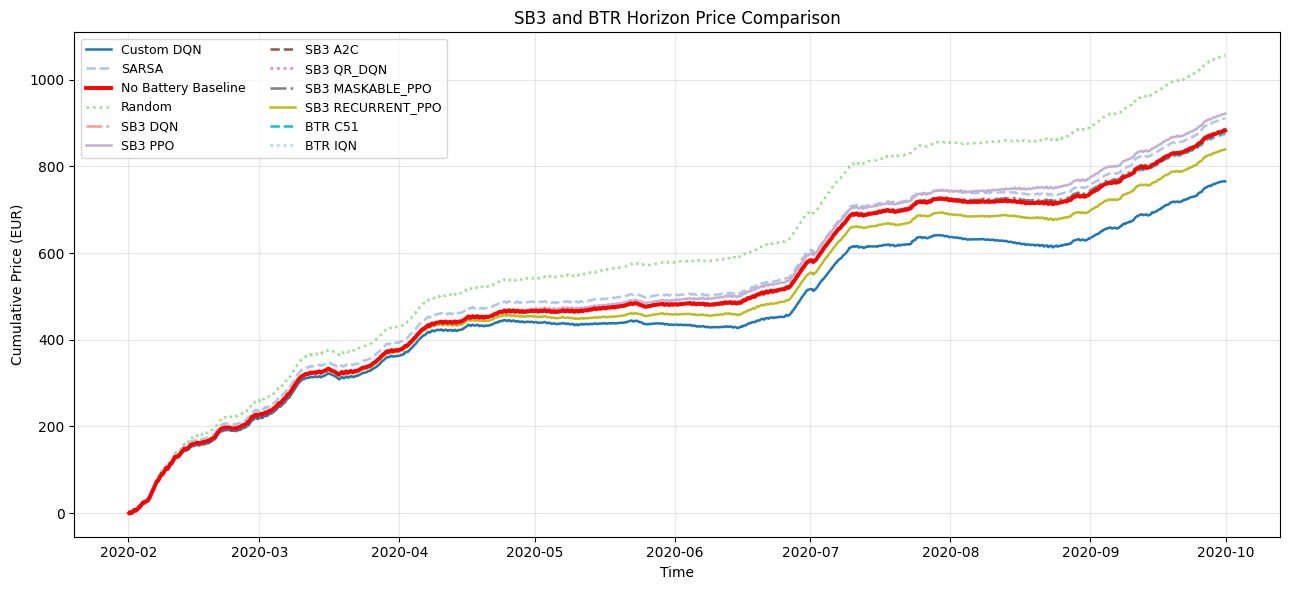

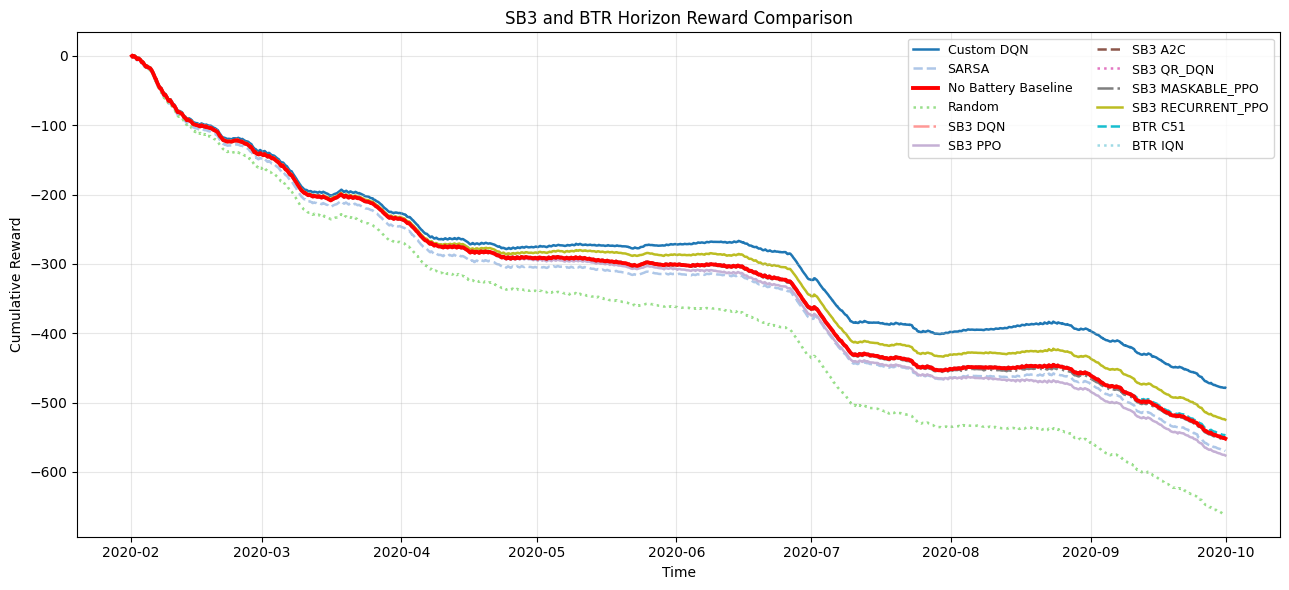

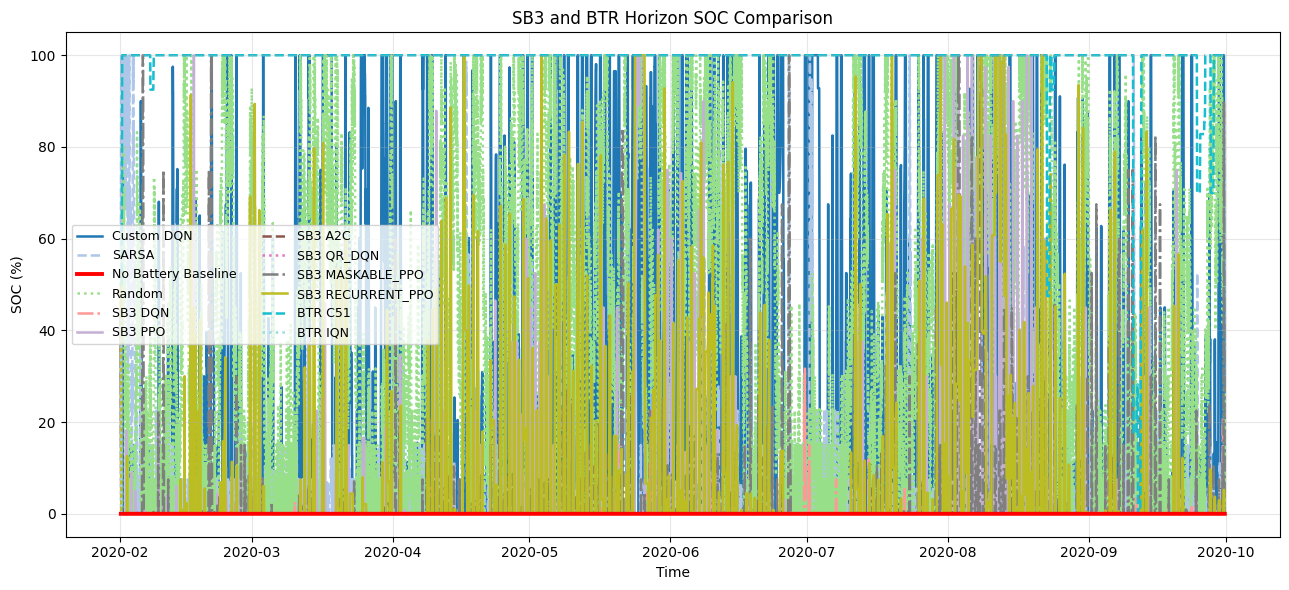

          algorithm  final_price  final_reward  vs_baseline_price  vs_baseline_reward  vs_baseline_price_%  vs_baseline_reward_%
         Custom DQN   765.504237   -478.440148        -117.734637           73.584148           -13.329875            -13.329875
  SB3 RECURRENT_PPO   839.617479   -524.760924         -43.621395           27.263372            -4.938799             -4.938799
            BTR C51   876.161932   -547.601208          -7.076942            4.423089            -0.801249             -0.801249
            SB3 DQN   881.564316   -550.977697          -1.674559            1.046599            -0.189593             -0.189593
            SB3 A2C   881.659824   -551.037390          -1.579050            0.986906            -0.178779             -0.178779
         SB3 QR_DQN   881.659824   -551.037390          -1.579050            0.986906            -0.178779             -0.178779
            BTR IQN   881.659824   -551.037390          -1.579050            0.986906            

In [83]:
from stable_baselines3 import DQN as SB3DQN, PPO as SB3PPO, A2C as SB3A2C
try:
    from sb3_contrib import QRDQN as SB3QRDQN, MaskablePPO as SB3MaskablePPO, RecurrentPPO as SB3RecurrentPPO
    SB3_CONTRIB_AVAILABLE = True
except ImportError:
    SB3QRDQN = None
    SB3MaskablePPO = None
    SB3RecurrentPPO = None
    SB3_CONTRIB_AVAILABLE = False

from btr_agent import BTRAgent

HORIZON_STEPS = len(test_data) - 1
HORIZON_INDEX = list(test_data.index[:HORIZON_STEPS])
BASELINE_LABEL = "No Battery Baseline"


def build_rollout_env(observation_mode):
    return HouseholdEnvironment(
        dataset=test_data,
        dataset_norm=test_data_norm,
        observation_mode=observation_mode,
        reset_mode="deterministic",
        episode_length=HORIZON_STEPS,
        korakov_na_dan=KorakovNaDan,
        bat_kapaciteta=BatKapaciteta,
        bat_ucinkovitost=BatUcinkovitost,
        bat_max_polnjenje=BatMaxPolnjenje,
        bat_max_praznjenje=BatMaxPraznjenje,
        faktor_cenitve=faktor_cenitve,
        faktor_n1=faktorN1,
        faktor_n2=faktorN2,
        faktor_n3=faktorN3,
    )


def trim_initial_zero(series, length):
    values = np.asarray(series, dtype=float)
    if values.size >= length + 1:
        return values[1:length + 1]
    return values[:length]


def collect_rollout(env, action_fn, horizon_steps):
    obs, info = env.reset(options={"reset_mode": "deterministic"})
    rewards = [0.0]
    prices = [float(info.get("cumulative_payment", 0.0))]
    soc = [100.0 * float(info.get("battery_norm", 0.0))]
    battery = [float(info.get("battery", 0.0))]

    done = False
    recurrent_state = None
    episode_start = np.array([True], dtype=bool)

    for _ in range(horizon_steps):
        action, recurrent_state, episode_start = action_fn(obs, recurrent_state, episode_start)
        obs, reward, terminated, truncated, step_info = env.step(action)
        done = bool(terminated or truncated)
        rewards.append(rewards[-1] + float(reward))
        prices.append(float(step_info.get("cumulative_payment", prices[-1])))
        battery_value = float(step_info.get("battery", battery[-1]))
        battery.append(battery_value)
        soc.append(100.0 * float(step_info.get("battery_norm", battery_value / env.bat_kapaciteta if env.bat_kapaciteta > 0 else 0.0)))
        episode_start = np.array([done], dtype=bool)
        if done:
            break

    return {
        "reward": np.asarray(rewards, dtype=float),
        "price": np.asarray(prices, dtype=float),
        "soc": np.asarray(soc, dtype=float),
        "battery": np.asarray(battery, dtype=float),
    }


def _sb3_action_fn(model, algorithm_name):
    def action_fn(obs, recurrent_state, episode_start):
        if algorithm_name == "RECURRENT_PPO":
            action, recurrent_state = model.predict(
                obs,
                state=recurrent_state,
                episode_start=episode_start,
                deterministic=True,
            )
            return int(action), recurrent_state, np.array([False], dtype=bool)
        action, _ = model.predict(obs, deterministic=True)
        return int(action), None, np.array([False], dtype=bool)

    return action_fn


def load_sb3_model(algorithm_name, model_path, env):
    sb3_map = {
        "DQN": SB3DQN,
        "PPO": SB3PPO,
        "A2C": SB3A2C,
        "QR_DQN": SB3QRDQN,
        "MASKABLE_PPO": SB3MaskablePPO,
        "RECURRENT_PPO": SB3RecurrentPPO,
    }
    model_cls = sb3_map.get(algorithm_name)
    if model_cls is None:
        return None
    if algorithm_name in {"QR_DQN", "MASKABLE_PPO", "RECURRENT_PPO"} and not SB3_CONTRIB_AVAILABLE:
        return None
    return model_cls.load(str(model_path), env=env)


def load_best_sb3_traces(base_dir=Path("SB3"), algorithms=("DQN", "PPO", "A2C", "QR_DQN", "MASKABLE_PPO", "RECURRENT_PPO")):
    traces = {}
    for algorithm_name in algorithms:
        algo_dir = base_dir / algorithm_name
        if not algo_dir.exists():
            continue
        model_files = sorted(algo_dir.glob("model_seed_*.zip"))
        if not model_files:
            continue
        model_file = min(
            model_files,
            key=lambda path: int(re.search(r"model_seed_(\d+)\.zip$", path.name).group(1)),
        )
        eval_env = build_rollout_env("sliding_window")
        model = load_sb3_model(algorithm_name, model_file, eval_env)
        if model is None:
            continue
        rollout = collect_rollout(eval_env, _sb3_action_fn(model, algorithm_name), HORIZON_STEPS)
        traces[f"SB3 {algorithm_name}"] = rollout
    return traces


def load_best_btr_traces(base_dir=Path("BTR")):
    results_path = base_dir / "btr_results.csv"
    if not results_path.exists():
        return {}

    results_df = pd.read_csv(results_path)
    traces = {}
    for algorithm_name in sorted(results_df["algorithm"].dropna().unique()):
        algo_rows = results_df[results_df["algorithm"] == algorithm_name].copy()
        if algo_rows.empty or "model_path" not in algo_rows.columns:
            continue
        best_row = algo_rows.sort_values(["price_mean", "reward_mean"], ascending=[True, True]).iloc[0]
        model_path = Path(best_row["model_path"])
        if not model_path.is_absolute():
            model_path = Path(".") / model_path
        if not model_path.exists():
            continue

        eval_env = build_rollout_env("compact")
        checkpoint = torch.load(str(model_path), map_location="cpu")
        config = checkpoint.get("config", {}) if isinstance(checkpoint, dict) else {}
        agent = BTRAgent(
            state_shape=eval_env.observation_space.shape[0],
            n_actions=eval_env.action_space.n,
            algorithm=algorithm_name,
            device="cpu",
            **config,
        )
        agent.load_checkpoint(str(model_path))

        def action_fn(obs, recurrent_state, episode_start):
            return int(agent.select_action(obs, training=False)), None, np.array([False], dtype=bool)

        rollout = collect_rollout(eval_env, action_fn, HORIZON_STEPS)
        traces[f"BTR {algorithm_name}"] = rollout
    return traces


def add_existing_trace(label, reward_series, price_series, soc_series, traces):
    traces[label] = {
        "reward": np.asarray(reward_series, dtype=float),
        "price": np.asarray(price_series, dtype=float),
        "soc": np.asarray(soc_series, dtype=float),
    }


def plot_horizon_series(x_axis, series_list, labels, title, y_label, save_path=None):
    fig, ax = plt.subplots(figsize=(13, 6))
    colors = plt.cm.tab20(np.linspace(0, 1, max(len(series_list), 1)))
    line_styles = ["-", "--", ":", "-."]
    
    non_baseline_idx = 0
    for idx, (label, series) in enumerate(zip(labels, series_list)):
        is_baseline = label == BASELINE_LABEL
        ax.plot(
            x_axis,
            series,
            label=label,
            color="red" if is_baseline else colors[idx],
            linestyle="-" if is_baseline else line_styles[non_baseline_idx % len(line_styles)],
            linewidth=2.8 if is_baseline else 1.8,
            zorder=10 if is_baseline else 1,
        )
        if not is_baseline:
            non_baseline_idx += 1

    ax.set_xlabel("Time")
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, ncol=2)
    fig.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()
    plt.close(fig)


comparison_traces = {}

if all(name in globals() for name in ["nagradaDQN", "placiloDQN", "baterijaDQN"]):
    add_existing_trace(
        "Custom DQN",
        nagradaDQN,
        placiloDQN,
        100.0 * np.asarray(baterijaDQN, dtype=float) / BatKapaciteta,
        comparison_traces,
    )
if all(name in globals() for name in ["agent_test"]) and hasattr(agent_test, "NagradaSkupno") and hasattr(agent_test, "Price") and hasattr(agent_test, "NapolnjenostBaterije"):
    add_existing_trace(
        "SARSA",
        agent_test.NagradaSkupno,
        agent_test.Price,
        100.0 * np.asarray(agent_test.NapolnjenostBaterije, dtype=float) / BatKapaciteta,
        comparison_traces,
    )
if all(name in globals() for name in ["agent_brez_baterije"]) and hasattr(agent_brez_baterije, "NagradaSkupno") and hasattr(agent_brez_baterije, "Price") and hasattr(agent_brez_baterije, "NapolnjenostBaterije"):
    add_existing_trace(
        BASELINE_LABEL,
        agent_brez_baterije.NagradaSkupno,
        agent_brez_baterije.Price,
        100.0 * np.asarray(agent_brez_baterije.NapolnjenostBaterije, dtype=float) / BatKapaciteta,
        comparison_traces,
    )
if all(name in globals() for name in ["nakljucni_nagradaDQN", "nakljucni_placiloDQN", "nakljucni_baterijaDQN"]):
    add_existing_trace(
        "Random",
        nakljucni_nagradaDQN,
        nakljucni_placiloDQN,
        100.0 * np.asarray(nakljucni_baterijaDQN, dtype=float) / BatKapaciteta,
        comparison_traces,
    )

comparison_traces.update(load_best_sb3_traces())
comparison_traces.update(load_best_btr_traces())

if not comparison_traces:
    raise RuntimeError("No trajectories were collected. Make sure the custom agents and benchmark models are available.")

common_steps = min(len(trace["reward"]) - 1 for trace in comparison_traces.values())
x_axis = HORIZON_INDEX[:common_steps]
labels = list(comparison_traces.keys())

# --- Step 1: Collect raw absolute data arrays for plots ---
price_plot = [trim_initial_zero(trace["price"], common_steps) for trace in comparison_traces.values()]
reward_plot = [trim_initial_zero(trace["reward"], common_steps) for trace in comparison_traces.values()]
soc_plot = [trim_initial_zero(trace["soc"], common_steps) for trace in comparison_traces.values()]

# --- Step 3: Automatically handle unique sequential numbering ---
output_dir = Path("plots") / "comparison"
output_dir.mkdir(parents=True, exist_ok=True)

existing_numbers = []
for file_path in list(output_dir.glob("*.png")) + list(output_dir.glob("*.csv")):
    found_digits = re.findall(r"\d+", file_path.name)
    if found_digits:
        existing_numbers.extend([int(d) for d in found_digits])

serial_num = max(existing_numbers) + 1 if existing_numbers else 1
serial_str = f"{serial_num:03d}"

price_img_path = output_dir / f"comparison_{serial_str}_price.png"
reward_img_path = output_dir / f"comparison_{serial_str}_reward.png"
soc_img_path = output_dir / f"comparison_{serial_str}_soc.png"

# Render and Save the Absolute Plots
plot_horizon_series(x_axis, price_plot, labels, "SB3 and BTR Horizon Price Comparison", "Cumulative Price (EUR)", save_path=price_img_path)
plot_horizon_series(x_axis, reward_plot, labels, "SB3 and BTR Horizon Reward Comparison", "Cumulative Reward", save_path=reward_img_path)
plot_horizon_series(x_axis, soc_plot, labels, "SB3 and BTR Horizon SOC Comparison", "SOC (%)", save_path=soc_img_path)

# --- Step 4: Save exact recreation data matching the absolute plots ---
price_data_df = pd.DataFrame(index=x_axis)
reward_data_df = pd.DataFrame(index=x_axis)
soc_data_df = pd.DataFrame(index=x_axis)

for label, p_data, r_data, s_data in zip(labels, price_plot, reward_plot, soc_plot):
    price_data_df[label] = p_data
    reward_data_df[label] = r_data
    soc_data_df[label] = s_data

price_data_df.to_csv(output_dir / f"comparison_{serial_str}_price_data.csv")
reward_data_df.to_csv(output_dir / f"comparison_{serial_str}_reward_data.csv")
soc_data_df.to_csv(output_dir / f"comparison_{serial_str}_soc_data.csv")

# --- Step 2: Compute summary table incorporating percentage metrics ---
summary_rows = []
for label, trace in comparison_traces.items():
    summary_rows.append({
        "algorithm": label,
        "final_price": float(trim_initial_zero(trace["price"], common_steps)[-1]),
        "final_reward": float(trim_initial_zero(trace["reward"], common_steps)[-1]),
    })

comparison_summary = pd.DataFrame(summary_rows).sort_values("final_price").reset_index(drop=True)

baseline_row = comparison_summary[comparison_summary["algorithm"] == BASELINE_LABEL]
if not baseline_row.empty:
    baseline_price = float(baseline_row["final_price"].iloc[0])
    baseline_reward = float(baseline_row["final_reward"].iloc[0])
    comparison_summary["vs_baseline_price"] = comparison_summary["final_price"] - baseline_price
    comparison_summary["vs_baseline_reward"] = comparison_summary["final_reward"] - baseline_reward
    
    if baseline_price != 0:
        comparison_summary["vs_baseline_price_%"] = (comparison_summary["vs_baseline_price"] / baseline_price) * 100
    if baseline_reward != 0:
        comparison_summary["vs_baseline_reward_%"] = (comparison_summary["vs_baseline_reward"] / baseline_reward) * 100

print(comparison_summary.to_string(index=False))